# Simple bifurcation example — NEN / time-layered formulation

This notebook uses a **non-autonomous / time-layered** ensemble-navigation model.
Every trajectory has one state at each `time_idx`.  The upper terminal branch is
used as a toy **extreme (EX)** outcome and the lower branch as a toy
**non-extreme (NE)** outcome.

For backward compatibility with the current `epsbasin.shortest_path` API, the
internal target keys are

- `good` $\leftrightarrow$ **EX**, and
- `bad` $\leftrightarrow$ **NE**.

All scientific output in this notebook uses the NEN notation

$$
C_{p,A}(t,x)=\text{minimum $\ell^p$-constrained perturbation cost to reach }A,
\qquad A\in\{\mathrm{EX},\mathrm{NE}\},
$$

and the **outcome commitment score**

$$
\boxed{S_p(t,x)=C_{p,\mathrm{NE}}(t,x)-C_{p,\mathrm{EX}}(t,x)}.
$$

Thus $S_p>0$ indicates commitment toward EX, $S_p<0$ indicates commitment
toward NE, and $|S_p|$ measures the strength of the commitment.

At forecast time $t_k$, a perturbation may switch from the current member $m$
to another member $n$ **only at the same time $t_k$**.  After that switch, the
selected member advances naturally to $t_{k+1}$.  For $p=\infty$ the recursion
uses a minimax/bottleneck cost; for $p=1$ it uses an additive cumulative cost.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
from sklearn.isotonic import IsotonicRegression

# Make the repository importable whether this notebook is launched from
# the repository root or from the examples directory.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "epsbasin").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import epsbasin
import epsbasin.shortest_path as shortest_path_module

print("epsbasin.shortest_path loaded from:", shortest_path_module.__file__)
assert hasattr(
    shortest_path_module,
    "minimum_epsilon_and_paths_to_good_bad",
), (
    "The loaded epsbasin/shortest_path.py does not contain "
    "minimum_epsilon_and_paths_to_good_bad. "
    "Replace it with the path-enabled shortest_path.py supplied with this notebook."
)

from epsbasin.shortest_path import (
    build_terminal_state_graph,
    eps_attracting_basin_shortest_path,
    eps_sum_attracting_basin_shortest_path,
    minimum_epsilon_to_good_bad,
    minimum_epsilon_and_paths_to_good_bad,
)


epsbasin.shortest_path loaded from: /home/dell2023/GitHub/eps-attracting-basin/epsbasin/shortest_path.py


## Generate the same type of two-branch time-series data

Only the last observation of each sequence is assigned an outcome: **EX** for the upper branch and **NE** for the lower branch. Intermediate observations are labelled `others`. The package-internal `cluster` keys remain `good` (EX) and `bad` (NE).

In [2]:
def hill_function(x, hill_coef=5, hill_half=2.0):
    x = np.asarray(x, dtype=float)
    return x**hill_coef / (hill_half**hill_coef + x**hill_coef)


def uniform_disk_noise(n, scale, rng):
    radius = scale * np.sqrt(rng.uniform(size=n))
    angle = rng.uniform(0.0, 2.0 * np.pi, size=n)
    return np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])


# Parameters
xlim = [0.0, 2.0]
xdiv = 20
scale = 5.0
hill_coef = 5
hill_half = 2.0
I = 20
noise_scale = 0.1
random_state = 0

rng = np.random.default_rng(random_state)
x = np.linspace(xlim[0], xlim[1], xdiv)
y = hill_function(x, hill_coef=hill_coef, hill_half=hill_half)

base_top = np.column_stack([x, y])
base_bottom = np.column_stack([x, -y])

sequences = []
seq_ids = []
time_indices = []
branch_labels = []

seq_id = 0
for branch_name, base in [("top", base_top), ("bottom", base_bottom)]:
    for _ in range(I):
        seq = base + uniform_disk_noise(xdiv, noise_scale, rng)
        sequences.append(scale * seq)
        seq_ids.extend([seq_id] * xdiv)
        time_indices.extend(range(xdiv))
        branch_labels.extend([branch_name] * xdiv)
        seq_id += 1

data_2d_flat = np.vstack(sequences)
seq_ids = np.asarray(seq_ids, dtype=int)
time_indices = np.asarray(time_indices, dtype=int)
branch_labels = np.asarray(branch_labels, dtype=object)

EX_CLUSTER_KEY = "good"   # legacy epsbasin API key -> extreme (EX)
NE_CLUSTER_KEY = "bad"    # legacy epsbasin API key -> non-extreme (NE)

cluster = np.full(data_2d_flat.shape[0], "others", dtype=object)
outcome = np.full(data_2d_flat.shape[0], "others", dtype=object)
for sid in np.unique(seq_ids):
    idx = np.flatnonzero(seq_ids == sid)
    terminal = idx[np.argmax(time_indices[idx])]
    if data_2d_flat[terminal, 1] > 0:
        cluster[terminal] = EX_CLUSTER_KEY
        outcome[terminal] = "EX"
    else:
        cluster[terminal] = NE_CLUSTER_KEY
        outcome[terminal] = "NE"

adata = ad.AnnData(X=data_2d_flat)
adata.obs = pd.DataFrame(
    {
        "seq_id": seq_ids,
        "time_idx": time_indices,
        "cluster": cluster,
        "outcome": outcome,
        "branch": branch_labels,
        "x": data_2d_flat[:, 0],
        "y": data_2d_flat[:, 1],
    },
    index=adata.obs_names.copy(),
)

adata

AnnData object with n_obs × n_vars = 800 × 2
    obs: 'seq_id', 'time_idx', 'cluster', 'outcome', 'branch', 'x', 'y'

In [3]:
# Confirm the terminal-outcome mapping used throughout the notebook.
terminal_rows = adata.obs.groupby("seq_id", sort=False).tail(1)
print(terminal_rows["outcome"].value_counts())
assert terminal_rows["outcome"].isin(["EX", "NE"]).all()
assert np.all((terminal_rows["cluster"] == EX_CLUSTER_KEY) == (terminal_rows["outcome"] == "EX"))
assert np.all((terminal_rows["cluster"] == NE_CLUSTER_KEY) == (terminal_rows["outcome"] == "NE"))

outcome
EX    20
NE    20
Name: count, dtype: int64


## Input trajectories

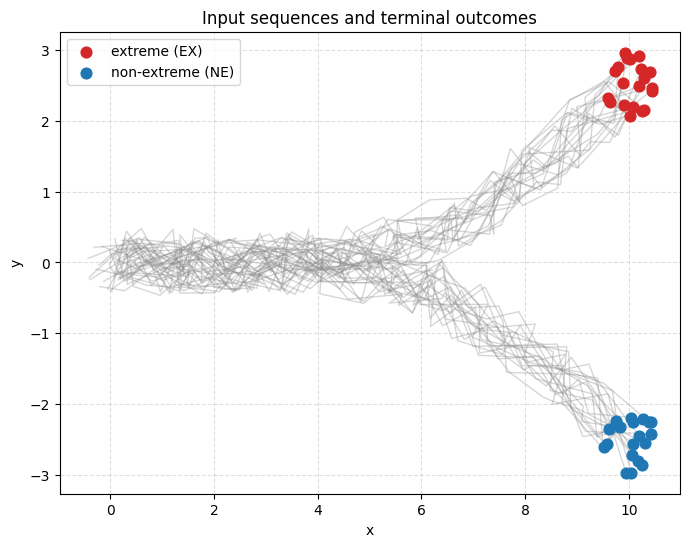

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    ax.plot(adata.X[idx, 0], adata.X[idx, 1], "-", color="0.55", lw=1, alpha=0.35)

mask_ex = adata.obs["outcome"].to_numpy() == "EX"
mask_ne = adata.obs["outcome"].to_numpy() == "NE"
ax.scatter(adata.X[mask_ex, 0], adata.X[mask_ex, 1], s=60, color="tab:red", label="extreme (EX)", zorder=5)
ax.scatter(adata.X[mask_ne, 0], adata.X[mask_ne, 1], s=60, color="tab:blue", label="non-extreme (NE)", zorder=5)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Input sequences and terminal outcomes")
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()

## Velocity vectors

The velocity is computed independently within each sequence by central differences, with one-sided differences at the endpoints.

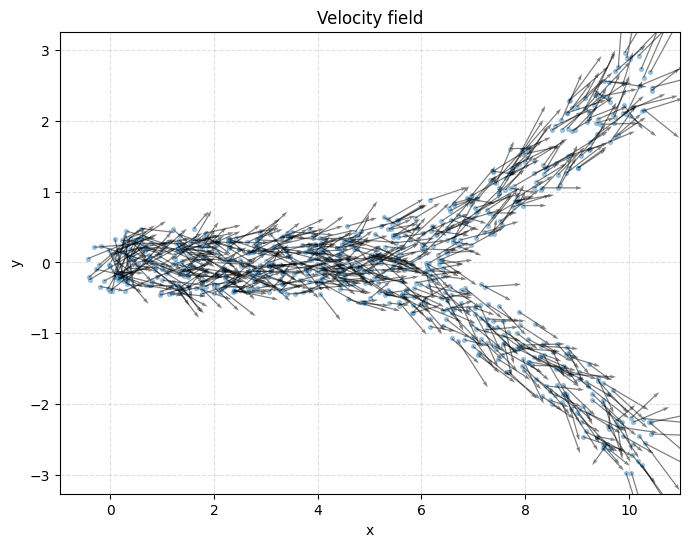

In [5]:
velocity = np.zeros_like(adata.X, dtype=float)

for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    points = np.asarray(adata.X[idx], dtype=float)

    if len(idx) == 1:
        velocity[idx] = 0.0
    elif len(idx) == 2:
        v = points[1] - points[0]
        velocity[idx[0]] = v
        velocity[idx[1]] = v
    else:
        velocity[idx[0]] = points[1] - points[0]
        velocity[idx[-1]] = points[-1] - points[-2]
        velocity[idx[1:-1]] = 0.5 * (points[2:] - points[:-2])

adata.obsm["velocity"] = velocity

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(adata.X[:, 0], adata.X[:, 1], s=8, alpha=0.35)
ax.quiver(
    adata.X[:, 0],
    adata.X[:, 1],
    velocity[:, 0],
    velocity[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1.0,
    width=0.002,
    alpha=0.5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Velocity field")
ax.grid(ls="--", alpha=0.4)
plt.show()


## Build and inspect the time-layered transition graph

With `transition_mode="time_layered"`, **cross-sequence costs are finite only between states with the same `time_idx`**. Same-sequence one-step forward dynamics has cost zero, while other inter-time jumps are infinite.

The inspection graph therefore implements the literal time restriction. The actual EX/NE reach costs are computed by backward dynamic programming rather than by Dijkstra on this graph, so that at most one same-time member switch is allowed per forecast step.


In [6]:
graph = build_terminal_state_graph(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
)

# Sanity checks for the literal time restriction.
seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
time_values = adata.obs["time_idx"].to_numpy(dtype=int)
first_seq = int(np.unique(seq_values)[0])
other_seq = int(np.unique(seq_values)[-1])

idx0 = np.flatnonzero(seq_values == first_seq)
idx0 = idx0[np.argsort(time_values[idx0])]
idx1 = np.flatnonzero(seq_values == other_seq)
idx1 = idx1[np.argsort(time_values[idx1])]

print("natural advance t0 -> t1:", graph.weights[idx0[0], idx0[1]])
print("forbidden direct t0 -> t2:", graph.weights[idx0[0], idx0[2]])
print("same-time cross-member t0 -> t0:", graph.weights[idx0[0], idx1[0]])
print("forbidden cross-member t0 -> t1:", graph.weights[idx0[0], idx1[1]])
print("number of terminal states:", len(graph.terminal_indices))


natural advance t0 -> t1: 0.0
forbidden direct t0 -> t2: inf
same-time cross-member t0 -> t0: 0.12333686917171811
forbidden cross-member t0 -> t1: inf
number of terminal states: 40


## Minimum perturbation costs for $p=\infty$: time-layered minimax recursion

For $p=\infty$, the non-autonomous recursion is

$$
C_{A,\infty}(m,k)
=
\min_n
\max\left\{
 d\bigl(x_m^k,x_n^k\bigr),
 C_{A,\infty}(n,k+1)
\right\}.
$$

Thus a trajectory can switch member at the current time but cannot jump to a different time index.

In [7]:
eps_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
    output_key="eps_attracting_basin_sp",
    distance_key="eps_distance_sp",
    terminal_class_key="terminal_class",
    store_next_hop=True,
)

adata.obs[[
    "cluster",
    "time_idx",
    "terminal_class",
    "eps_attracting_basin_sp_good",
    "eps_attracting_basin_sp_bad",
    "eps_attracting_basin_sp_landscape",
]].head()

,cluster,time_idx,terminal_class,eps_attracting_basin_sp_good,eps_attracting_basin_sp_bad,eps_attracting_basin_sp_landscape
0,others,0,good,-0.043361,0.043361,-0.043361
1,others,1,good,-0.043361,0.043361,-0.043361
2,others,2,good,-0.043361,0.043361,-0.043361
3,others,3,good,-0.043361,0.043361,-0.043361
4,others,4,good,-0.043361,0.043361,-0.043361


## Minimum perturbation costs for $p=1$: time-layered additive recursion

For $p=1$, the cumulative-cost recursion is

$$
C_{A,1}(m,k)
=
\min_n
\left[
 d\bigl(x_m^k,x_n^k\bigr)
 + C_{A,1}(n,k+1)
\right].
$$

Only one same-time member switch is allowed at each forecast step.

In [8]:
eps_sum_attracting_basin_shortest_path(
    adata,
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    sequence_edge_mode="adjacent",
    transition_mode="time_layered",
    output_key="eps_sum_attracting_basin_sp",
    distance_key="eps_sum_distance_sp",
)

adata.obs[[
    "cluster",
    "time_idx",
    "eps_sum_attracting_basin_sp_good",
    "eps_sum_attracting_basin_sp_bad",
    "eps_sum_attracting_basin_sp_landscape",
]].head()

,cluster,time_idx,eps_sum_attracting_basin_sp_good,eps_sum_attracting_basin_sp_bad,eps_sum_attracting_basin_sp_landscape
0,others,0,-0.043361,0.043361,-0.043361
1,others,1,-0.043361,0.043361,-0.043361
2,others,2,-0.043361,0.043361,-0.043361
3,others,3,-0.043361,0.043361,-0.043361
4,others,4,-0.043361,0.043361,-0.043361


## Query an arbitrary state $x$: $C_{p,\mathrm{EX}}$, $C_{p,\mathrm{NE}}$, $S_p$, and realizing paths

After the ensemble fields have been learned, an external state $x$ at time
$t_k$ is queried by supplying its cost to the ensemble states.  In the
**time-layered** model, only ensemble states at the same `time_idx` are
admissible entry states.

The current package helper uses the legacy names `good` and `bad`; here they are
interpreted as

$$
C_{p,\mathrm{EX}}=C_{p,\mathrm{good}},\qquad
C_{p,\mathrm{NE}}=C_{p,\mathrm{bad}}.
$$

The NEN outcome commitment score is

$$
\boxed{S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}}.
$$

For each target outcome, the helper also returns one minimum-cost controlled
path.  Dashed arrows indicate perturbations (entry / same-time switches), and
solid arrows indicate zero-cost natural time evolution.

In [9]:
# A query chosen early enough that the L1 and L-infinity optimal paths
# can differ.  This state is not one of the ensemble observations.
QUERY_TIME_IDX = 8
x_query = np.array([4.2, 0.2], dtype=float)

# Cost from x to the ensemble.  For the time-layered query we make the
# same-time restriction explicit by setting all other time layers to infinity.
query_costs = np.full(adata.n_obs, np.inf, dtype=float)
same_time_mask = (
    adata.obs["time_idx"].to_numpy(dtype=int) == QUERY_TIME_IDX
)
X_same_time = np.asarray(adata.X[same_time_mask], dtype=float)
query_costs[same_time_mask] = np.linalg.norm(
    X_same_time - x_query[None, :],
    axis=1,
)

query_result_inf = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_query,
    query_costs,
    output_key="eps_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
)
query_result_one = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_query,
    query_costs,
    output_key="eps_sum_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
)

for name, result in [
    (r"$p=\infty$", query_result_inf),
    (r"$p=1$", query_result_one),
]:
    print(
        f"{name}: "
        f"C_EX={result.epsilon_good:.4f}, "
        f"C_NE={result.epsilon_bad:.4f}, "
        f"S=C_NE-C_EX={result.score_good:.4f}"
    )
    print(
        "  realized by paths: "
        f"EX={result.path_good.realized_value:.4f}, "
        f"NE={result.path_bad.realized_value:.4f}"
    )
    assert np.isclose(
        result.path_good.realized_value,
        result.epsilon_good,
    )
    assert np.isclose(
        result.path_bad.realized_value,
        result.epsilon_bad,
    )


def optimal_path_table(path, adata_obj):
    """Human-readable table of the transitions in one reconstructed path."""
    rows = []
    for step_no, step in enumerate(path.steps):
        if step.source_index is None:
            source = "x"
            source_seq = "external"
            source_time = QUERY_TIME_IDX
        else:
            source = int(step.source_index)
            source_seq = adata_obj.obs.iloc[step.source_index]["seq_id"]
            source_time = adata_obj.obs.iloc[step.source_index]["time_idx"]

        destination = int(step.destination_index)
        rows.append(
            {
                "step": step_no,
                "kind": step.kind,
                "source": source,
                "source_seq": source_seq,
                "source_time": source_time,
                "destination": destination,
                "destination_seq": adata_obj.obs.iloc[destination]["seq_id"],
                "destination_time": adata_obj.obs.iloc[destination]["time_idx"],
                "cost": step.cost,
            }
        )
    return pd.DataFrame(rows)


print("\nL-infinity path to EX")
display(optimal_path_table(query_result_inf.path_good, adata))
print("L-infinity path to NE")
display(optimal_path_table(query_result_inf.path_bad, adata))
print("L1 path to EX")
display(optimal_path_table(query_result_one.path_good, adata))
print("L1 path to NE")
display(optimal_path_table(query_result_one.path_bad, adata))

$p=\infty$: C_EX=0.0893, C_NE=0.1155, S=C_NE-C_EX=0.0262
  realized by paths: EX=0.0893, NE=0.1155
$p=1$: C_EX=0.0893, C_NE=0.1626, S=C_NE-C_EX=0.0733
  realized by paths: EX=0.0893, NE=0.1626

L-infinity path to EX


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,28,1,8,0.089276
1,1,advance,28,1,8,29,1,9,0.000000
2,2,advance,29,1,9,30,1,10,0.000000
3,3,advance,30,1,10,31,1,11,0.000000
4,4,advance,31,1,11,32,1,12,0.000000
5,5,advance,32,1,12,33,1,13,0.000000
6,6,advance,33,1,13,34,1,14,0.000000
7,7,advance,34,1,14,35,1,15,0.000000
8,8,advance,35,1,15,36,1,16,0.000000
9,9,advance,36,1,16,37,1,17,0.000000


L-infinity path to NE


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,128,6,8,0.115482
1,1,advance,128,6,8,129,6,9,0.000000
2,2,switch,129,6,9,469,23,9,0.062261
3,3,advance,469,23,9,470,23,10,0.000000
4,4,advance,470,23,10,471,23,11,0.000000
5,5,advance,471,23,11,472,23,12,0.000000
6,6,advance,472,23,12,473,23,13,0.000000
7,7,advance,473,23,13,474,23,14,0.000000
8,8,advance,474,23,14,475,23,15,0.000000
9,9,advance,475,23,15,476,23,16,0.000000


L1 path to EX


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,28,1,8,0.089276
1,1,advance,28,1,8,29,1,9,0.000000
2,2,advance,29,1,9,30,1,10,0.000000
3,3,advance,30,1,10,31,1,11,0.000000
4,4,advance,31,1,11,32,1,12,0.000000
5,5,advance,32,1,12,33,1,13,0.000000
6,6,advance,33,1,13,34,1,14,0.000000
7,7,advance,34,1,14,35,1,15,0.000000
8,8,advance,35,1,15,36,1,16,0.000000
9,9,advance,36,1,16,37,1,17,0.000000


L1 path to NE


,step,kind,source,source_seq,source_time,destination,destination_seq,destination_time,cost
0,0,entry,x,external,8,748,37,8,0.162571
1,1,advance,748,37,8,749,37,9,0.000000
2,2,advance,749,37,9,750,37,10,0.000000
3,3,advance,750,37,10,751,37,11,0.000000
4,4,advance,751,37,11,752,37,12,0.000000
5,5,advance,752,37,12,753,37,13,0.000000
6,6,advance,753,37,13,754,37,14,0.000000
7,7,advance,754,37,14,755,37,15,0.000000
8,8,advance,755,37,15,756,37,16,0.000000
9,9,advance,756,37,16,757,37,17,0.000000


### State-space visualization of the optimal EX/NE paths

The gray curves are the training ensemble trajectories and the black star is
the external query $x$. Red and blue indicate paths toward EX and NE,
respectively.

To make the intervention timing explicit, the two transition types are drawn
differently:

- **CONTROL (entry / same-time switch):** thick dashed, slightly curved arrow
  with a large arrowhead. The state immediately after control is marked by a
  diamond, and the perturbation magnitude is labeled as
  $\varepsilon=\mathrm{cost}$.
- **TIME EVOLUTION (natural advance):** thinner solid straight arrow. This is
  the zero-cost evolution of the selected ensemble member to the next time
  layer.

Thus every dashed arrow identifies exactly where a control perturbation is
inserted, whereas every solid arrow represents uncontrolled temporal
evolution.

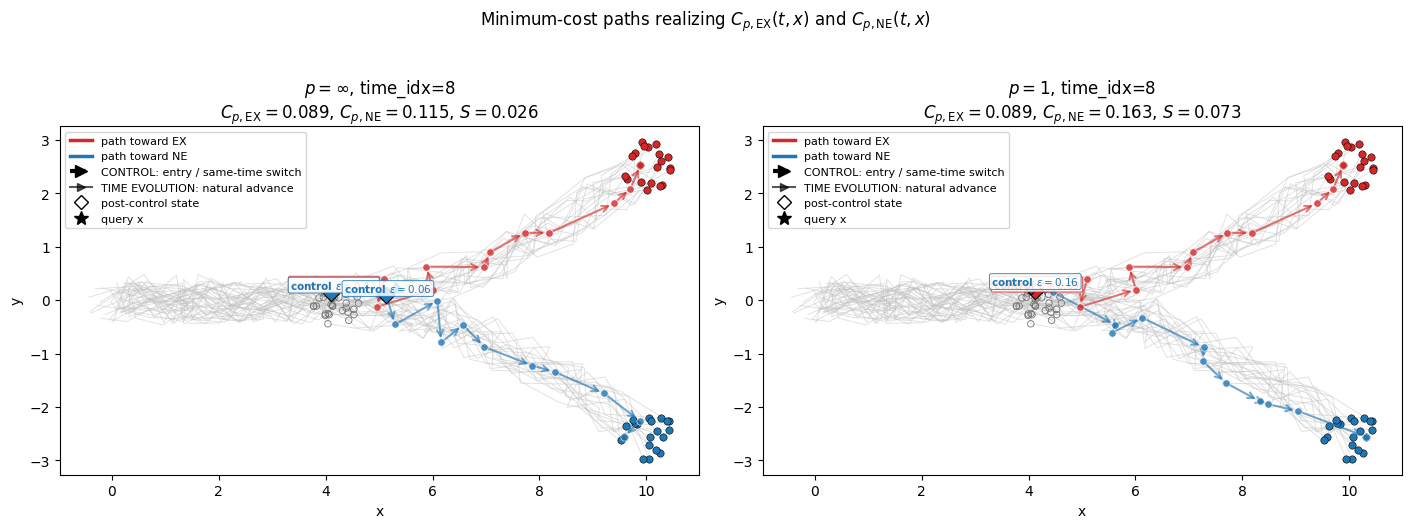

In [10]:
from matplotlib.lines import Line2D


def plot_query_paths(ax, result, *, title):
    X_all = np.asarray(adata.X, dtype=float)
    seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
    time_values = adata.obs["time_idx"].to_numpy(dtype=int)

    # Background ensemble trajectories.
    for seq_id in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == seq_id)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(
            X_all[idx, 0],
            X_all[idx, 1],
            color="0.75",
            linewidth=0.7,
            alpha=0.45,
            zorder=1,
        )

    # Ensemble states available at the query time.
    same_time_indices = np.flatnonzero(time_values == QUERY_TIME_IDX)
    ax.scatter(
        X_all[same_time_indices, 0],
        X_all[same_time_indices, 1],
        s=22,
        facecolors="none",
        edgecolors="0.45",
        linewidths=0.6,
        zorder=2,
    )

    # Terminal outcomes.
    terminal_ex = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == EX_CLUSTER_KEY
    )
    terminal_ne = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == NE_CLUSTER_KEY
    )
    ax.scatter(
        X_all[terminal_ex, 0],
        X_all[terminal_ex, 1],
        s=28,
        color="tab:red",
        marker="o",
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
    )
    ax.scatter(
        X_all[terminal_ne, 0],
        X_all[terminal_ne, 1],
        s=28,
        color="tab:blue",
        marker="o",
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
    )

    # External query state.
    ax.scatter(
        [x_query[0]],
        [x_query[1]],
        s=140,
        marker="*",
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=10,
    )

    def draw_optimal_path(path, color):
        """
        Draw one optimal path with two visually distinct transition types.

        CONTROL (entry / same-time switch)
          - thick dashed arrow
          - large filled arrow head
          - slight curvature
          - diamond at the post-control state
          - epsilon/cost label

        TIME EVOLUTION (natural advance)
          - thinner solid straight arrow
          - ordinary arrow head
          - no perturbation-cost label
        """
        visited = []
        control_destinations = []

        for step in path.steps:
            if step.source_index is None:
                p0 = x_query
            else:
                p0 = X_all[int(step.source_index)]
            p1 = X_all[int(step.destination_index)]

            is_control = step.kind in {"entry", "switch", "graph"}

            if is_control:
                # Perturbative control: same-time jump / entry.
                arrowprops = dict(
                    arrowstyle="-|>",
                    color=color,
                    linewidth=3.0,
                    linestyle="--",
                    mutation_scale=17,
                    shrinkA=4,
                    shrinkB=5,
                    alpha=1.0,
                    connectionstyle="arc3,rad=0.10",
                )
                zorder = 9
            else:
                # Natural time evolution: same member advances to next time.
                arrowprops = dict(
                    arrowstyle="->",
                    color=color,
                    linewidth=1.5,
                    linestyle="-",
                    mutation_scale=11,
                    shrinkA=3,
                    shrinkB=3,
                    alpha=0.60,
                    connectionstyle="arc3,rad=0.0",
                )
                zorder = 6

            ax.annotate(
                "",
                xy=(p1[0], p1[1]),
                xytext=(p0[0], p0[1]),
                arrowprops=arrowprops,
                zorder=zorder,
            )

            if is_control:
                control_destinations.append(int(step.destination_index))

                # Explicitly label where the perturbation/control is applied.
                midpoint = 0.5 * (p0 + p1)
                if step.cost > 1e-10:
                    label = rf"control $\varepsilon={step.cost:.2f}$"
                else:
                    label = "control"

                ax.text(
                    midpoint[0],
                    midpoint[1],
                    label,
                    color=color,
                    fontsize=7.5,
                    fontweight="bold",
                    ha="center",
                    va="bottom",
                    bbox=dict(
                        boxstyle="round,pad=0.18",
                        facecolor="white",
                        edgecolor=color,
                        linewidth=0.7,
                        alpha=0.85,
                    ),
                    zorder=12,
                )

            visited.append(int(step.destination_index))

        # States used by the optimal path.
        if visited:
            unique_visited = np.unique(visited)
            ax.scatter(
                X_all[unique_visited, 0],
                X_all[unique_visited, 1],
                s=28,
                facecolor=color,
                edgecolor="white",
                linewidth=0.5,
                alpha=0.80,
                zorder=8,
            )

        # Diamond markers make control locations immediately visible.
        if control_destinations:
            control_destinations = np.unique(control_destinations)
            ax.scatter(
                X_all[control_destinations, 0],
                X_all[control_destinations, 1],
                s=70,
                marker="D",
                facecolor=color,
                edgecolor="black",
                linewidth=0.8,
                zorder=11,
            )

    draw_optimal_path(result.path_good, "tab:red")
    draw_optimal_path(result.path_bad, "tab:blue")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(
        title
        + "\n"
        + rf"$C_{{p,\mathrm{{EX}}}}={result.epsilon_good:.3f}$, "
          rf"$C_{{p,\mathrm{{NE}}}}={result.epsilon_bad:.3f}$, "
          rf"$S={result.score_good:.3f}$"
    )

    legend_handles = [
        Line2D(
            [0], [0], color="tab:red", lw=2.5,
            label="path toward EX",
        ),
        Line2D(
            [0], [0], color="tab:blue", lw=2.5,
            label="path toward NE",
        ),
        Line2D(
            [0], [0], color="black", lw=3.0, ls="--",
            marker=">", markevery=[1], markersize=8,
            label="CONTROL: entry / same-time switch",
        ),
        Line2D(
            [0], [0], color="black", lw=1.5, ls="-", alpha=0.65,
            marker=">", markevery=[1], markersize=6,
            label="TIME EVOLUTION: natural advance",
        ),
        Line2D(
            [0], [0], marker="D", color="black", lw=0,
            markerfacecolor="white", markersize=7,
            label="post-control state",
        ),
        Line2D(
            [0], [0], marker="*", color="black", lw=0,
            markersize=10, label="query x",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        frameon=True,
        fontsize=8,
        loc="upper left",
    )


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.6),
    constrained_layout=True,
)
plot_query_paths(
    axes[0],
    query_result_inf,
    title=rf"$p=\infty$, time_idx={QUERY_TIME_IDX}",
)
plot_query_paths(
    axes[1],
    query_result_one,
    title=rf"$p=1$, time_idx={QUERY_TIME_IDX}",
)
fig.suptitle(
    r"Minimum-cost paths realizing $C_{p,\mathrm{EX}}(t,x)$ and $C_{p,\mathrm{NE}}(t,x)$",
    y=1.02,
)
plt.show()

## Norm-dependent plan in the **same Hill-branch dynamics**

This example uses the original `adata` ensemble generated above; **no extra trajectories or artificial relay system are introduced**.

We select one state already contained in the NE ensemble (`seq_id = 38`, `time_idx = 4`) and ask for a plan toward the same target outcome EX under the two perturbation norms.  For the current random seed and dynamics, the two norms prefer qualitatively different plans:

- $p=1$ prefers a **single larger switch**, because it minimizes the total accumulated perturbation.
- $p=\infty$ prefers a **relay of several smaller switches**, because it minimizes the largest perturbation amplitude.

Thus the difference in plan is produced by the same noisy Hill-branch ensemble used throughout the notebook, rather than by a separately designed example.

In [11]:
# -----------------------------------------------------------------------------
# Norm-dependent EX plan using the ORIGINAL Hill-branch ensemble `adata`.
# -----------------------------------------------------------------------------
PLAN_DEMO_SEQ_ID = 38
PLAN_DEMO_TIME_IDX = 4

seq_values_demo = adata.obs["seq_id"].to_numpy(dtype=int)
time_values_demo = adata.obs["time_idx"].to_numpy(dtype=int)

query_obs = np.flatnonzero(
    (seq_values_demo == PLAN_DEMO_SEQ_ID)
    & (time_values_demo == PLAN_DEMO_TIME_IDX)
)
if query_obs.size != 1:
    raise RuntimeError("Could not identify the requested demonstration state uniquely.")

PLAN_DEMO_OBS_INDEX = int(query_obs[0])
x_plan_demo = np.asarray(adata.X[PLAN_DEMO_OBS_INDEX], dtype=float).copy()

# Euclidean cost from the query to the ensemble at the SAME time layer only.
plan_demo_query_costs = np.full(adata.n_obs, np.inf, dtype=float)
mask_plan_time = time_values_demo == PLAN_DEMO_TIME_IDX
plan_demo_query_costs[mask_plan_time] = np.linalg.norm(
    np.asarray(adata.X[mask_plan_time], dtype=float) - x_plan_demo[None, :],
    axis=1,
)

# The learned fields are the same ones used elsewhere in this notebook.
plan_demo_inf = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_plan_demo,
    plan_demo_query_costs,
    output_key="eps_attracting_basin_sp",
    time_value=PLAN_DEMO_TIME_IDX,
)
plan_demo_one = minimum_epsilon_and_paths_to_good_bad(
    adata,
    x_plan_demo,
    plan_demo_query_costs,
    output_key="eps_sum_attracting_basin_sp",
    time_value=PLAN_DEMO_TIME_IDX,
)


def nonzero_control_steps(path, tol=1e-10):
    return [
        step
        for step in path.steps
        if step.kind in {"entry", "switch", "graph"}
        and float(step.cost) > tol
    ]


def control_step_table(path, adata_obj):
    rows = []
    control_no = 0
    for step in path.steps:
        if step.kind not in {"entry", "switch", "graph"}:
            continue
        if float(step.cost) <= 1e-10:
            continue
        control_no += 1

        if step.source_index is None:
            source_seq = "query x"
            source_time = PLAN_DEMO_TIME_IDX
        else:
            source_seq = int(adata_obj.obs.iloc[int(step.source_index)]["seq_id"])
            source_time = int(adata_obj.obs.iloc[int(step.source_index)]["time_idx"])

        destination = int(step.destination_index)
        rows.append(
            {
                "control": control_no,
                "kind": step.kind,
                "time_idx": source_time,
                "source_seq": source_seq,
                "destination_seq": int(adata_obj.obs.iloc[destination]["seq_id"]),
                "epsilon_i": float(step.cost),
            }
        )
    return pd.DataFrame(rows)


controls_one_steps = nonzero_control_steps(plan_demo_one.path_good)  # good == EX
controls_inf_steps = nonzero_control_steps(plan_demo_inf.path_good)
controls_one = [float(step.cost) for step in controls_one_steps]
controls_inf = [float(step.cost) for step in controls_inf_steps]

plan_demo_summary = pd.DataFrame(
    [
        {
            "p": "1",
            "C_p,EX": float(plan_demo_one.epsilon_good),
            "n_nonzero_controls": len(controls_one),
            "control_amplitudes": np.round(controls_one, 5).tolist(),
            "sum_epsilon": float(np.sum(controls_one)),
            "max_epsilon": float(np.max(controls_one)),
        },
        {
            "p": "infinity",
            "C_p,EX": float(plan_demo_inf.epsilon_good),
            "n_nonzero_controls": len(controls_inf),
            "control_amplitudes": np.round(controls_inf, 5).tolist(),
            "sum_epsilon": float(np.sum(controls_inf)),
            "max_epsilon": float(np.max(controls_inf)),
        },
    ]
)

print(
    f"Query taken from the original ensemble: seq_id={PLAN_DEMO_SEQ_ID}, "
    f"time_idx={PLAN_DEMO_TIME_IDX}, x={np.round(x_plan_demo, 4)}"
)
display(plan_demo_summary)

print("p=1 controls toward EX")
display(control_step_table(plan_demo_one.path_good, adata))
print("p=infinity controls toward EX")
display(control_step_table(plan_demo_inf.path_good, adata))

# Qualitative checks for the current deterministic example:
# p=1 uses one larger perturbation, whereas p=infinity spreads the plan over
# several smaller perturbations.  These assertions make the intended contrast
# explicit without introducing any new dynamics.
assert len(controls_one) == 1
assert len(controls_inf) >= 3
assert np.sum(controls_one) < np.sum(controls_inf)
assert np.max(controls_inf) < np.max(controls_one)

print("\nInterpretation")
print(
    "  p=1        : smaller total perturbation -> one larger switch "
    f"(sum={np.sum(controls_one):.4f})"
)
print(
    "  p=infinity : smaller worst-case perturbation -> relay of smaller switches "
    f"(max={np.max(controls_inf):.4f})"
)

Query taken from the original ensemble: seq_id=38, time_idx=4, x=[ 2.3664 -0.4235]


,p,"C_p,EX",n_nonzero_controls,control_amplitudes,sum_epsilon,max_epsilon
0,1,0.059035,1,[0.05903],0.059035,0.059035
1,infinity,0.028093,3,"[0.02809, 0.0234, 0.02403]",0.075520,0.028093


p=1 controls toward EX


,control,kind,time_idx,source_seq,destination_seq,epsilon_i
0,1,switch,5,38,13,0.059035


p=infinity controls toward EX


,control,kind,time_idx,source_seq,destination_seq,epsilon_i
0,1,entry,4,query x,34,0.028093
1,2,switch,7,34,26,0.023397
2,3,switch,10,26,14,0.024030



Interpretation
  p=1        : smaller total perturbation -> one larger switch (sum=0.0590)
  p=infinity : smaller worst-case perturbation -> relay of smaller switches (max=0.0281)


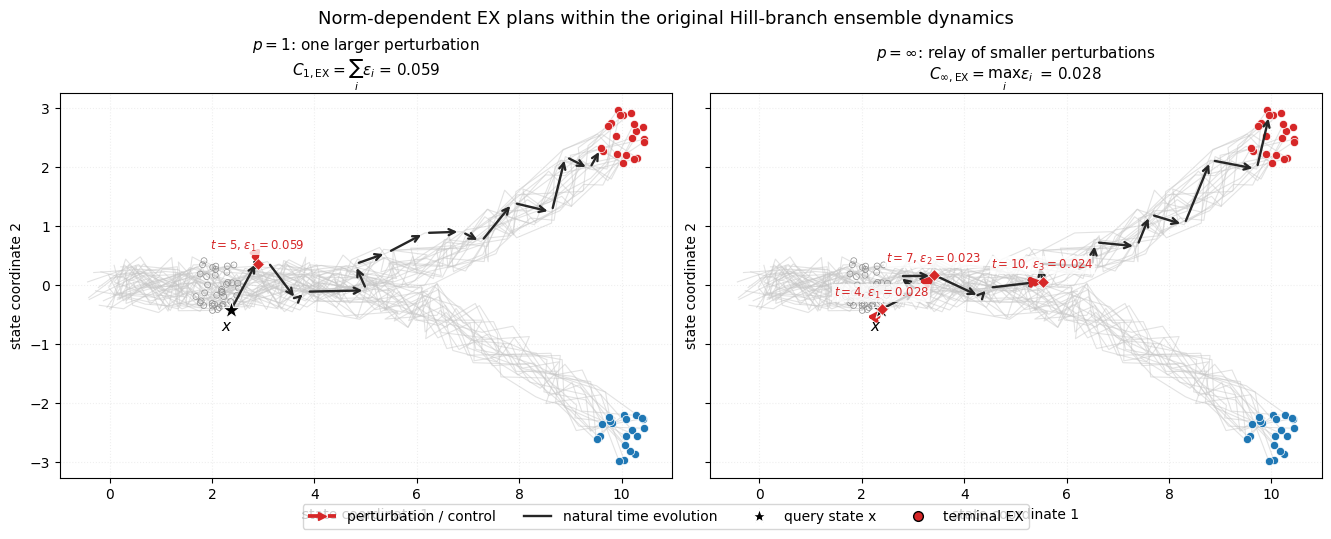

In [12]:
from matplotlib.lines import Line2D


def plot_same_dynamics_plan(ax, result, *, p_label):
    X_all = np.asarray(adata.X, dtype=float)
    seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
    time_values = adata.obs["time_idx"].to_numpy(dtype=int)

    # Original ensemble dynamics in gray.
    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(
            X_all[idx, 0],
            X_all[idx, 1],
            color="0.78",
            linewidth=0.8,
            alpha=0.50,
            zorder=1,
        )

    # States in the query time layer.
    same_time = np.flatnonzero(time_values == PLAN_DEMO_TIME_IDX)
    ax.scatter(
        X_all[same_time, 0],
        X_all[same_time, 1],
        s=18,
        facecolors="none",
        edgecolors="0.55",
        linewidths=0.5,
        zorder=2,
    )

    # Terminal outcomes.
    terminal_ex = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == EX_CLUSTER_KEY
    )
    terminal_ne = np.flatnonzero(
        adata.obs["cluster"].astype(str).to_numpy() == NE_CLUSTER_KEY
    )
    ax.scatter(
        X_all[terminal_ex, 0], X_all[terminal_ex, 1],
        s=35, color="tab:red", edgecolor="white", linewidth=0.5,
        zorder=4,
    )
    ax.scatter(
        X_all[terminal_ne, 0], X_all[terminal_ne, 1],
        s=35, color="tab:blue", edgecolor="white", linewidth=0.5,
        zorder=4,
    )

    # Query state: this is an actual state of the original ensemble.
    ax.scatter(
        [x_plan_demo[0]], [x_plan_demo[1]],
        marker="*", s=180, color="black", edgecolor="white",
        linewidth=0.8, zorder=10,
    )
    ax.text(
        x_plan_demo[0] - 0.20,
        x_plan_demo[1] - 0.35,
        r"$x$",
        fontsize=11,
        zorder=11,
    )

    # EX-optimal plan.  Red dashed = perturbation; dark solid = natural evolution.
    path = result.path_good
    control_number = 0
    for step in path.steps:
        p0 = x_plan_demo if step.source_index is None else X_all[int(step.source_index)]
        p1 = X_all[int(step.destination_index)]
        is_control = step.kind in {"entry", "switch", "graph"}

        # A zero-cost entry to the same ensemble state has zero geometric length;
        # do not draw or number it as an intervention.
        if is_control and float(step.cost) <= 1e-10:
            continue

        if is_control:
            control_number += 1
            ax.annotate(
                "",
                xy=p1,
                xytext=p0,
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="tab:red",
                    linewidth=2.7,
                    linestyle="--",
                    mutation_scale=15,
                    shrinkA=4,
                    shrinkB=4,
                    connectionstyle="arc3,rad=0.08",
                ),
                zorder=9,
            )
            midpoint = 0.5 * (p0 + p1)
            source_time = (
                PLAN_DEMO_TIME_IDX
                if step.source_index is None
                else int(adata.obs.iloc[int(step.source_index)]["time_idx"])
            )
            ax.text(
                midpoint[0],
                midpoint[1] + 0.22,
                rf"$t={source_time}$, $\varepsilon_{{{control_number}}}={step.cost:.3f}$",
                color="tab:red",
                fontsize=8.5,
                ha="center",
                bbox=dict(
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.78,
                    pad=1.0,
                ),
                zorder=10,
            )
            ax.scatter(
                [p1[0]], [p1[1]],
                marker="D", s=36, color="tab:red", edgecolor="white",
                linewidth=0.5, zorder=10,
            )
        else:
            ax.annotate(
                "",
                xy=p1,
                xytext=p0,
                arrowprops=dict(
                    arrowstyle="->",
                    color="0.15",
                    linewidth=1.7,
                    mutation_scale=11,
                    shrinkA=3,
                    shrinkB=3,
                ),
                zorder=7,
            )

    controls = [float(step.cost) for step in nonzero_control_steps(path)]
    if result.path_cost == "sum":
        cost_text = (
            r"$C_{1,\mathrm{EX}}=\sum_i\varepsilon_i$"
            + f" = {result.epsilon_good:.3f}"
        )
    else:
        cost_text = (
            r"$C_{\infty,\mathrm{EX}}=\max_i\varepsilon_i$"
            + f" = {result.epsilon_good:.3f}"
        )

    ax.set_title(p_label + "\n" + cost_text, fontsize=11)
    ax.set_xlabel("state coordinate 1")
    ax.set_ylabel("state coordinate 2")
    ax.grid(ls=":", alpha=0.20)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.2, 5.2),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
plot_same_dynamics_plan(
    axes[0],
    plan_demo_one,
    p_label=r"$p=1$: one larger perturbation",
)
plot_same_dynamics_plan(
    axes[1],
    plan_demo_inf,
    p_label=r"$p=\infty$: relay of smaller perturbations",
)

legend_handles = [
    Line2D(
        [0], [0], color="tab:red", linewidth=2.7, linestyle="--",
        marker=">", markevery=[1], label="perturbation / control",
    ),
    Line2D(
        [0], [0], color="0.15", linewidth=1.7,
        label="natural time evolution",
    ),
    Line2D(
        [0], [0], marker="*", color="none", markerfacecolor="black",
        markeredgecolor="white", markersize=11, label="query state x",
    ),
    Line2D(
        [0], [0], marker="o", color="none", markerfacecolor="tab:red",
        markersize=7, label="terminal EX",
    ),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)
fig.suptitle(
    "Norm-dependent EX plans within the original Hill-branch ensemble dynamics",
    fontsize=13,
)
plt.show()

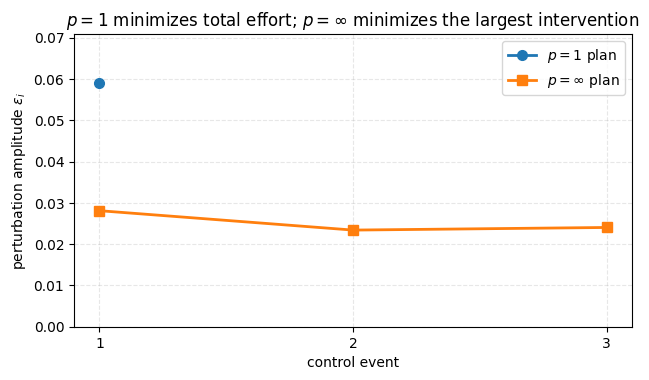

In [13]:
# The distinction can also be seen directly in the perturbation-amplitude profile.
# `controls_one` and `controls_inf` are computed from the EX-optimal paths above.
fig, ax = plt.subplots(figsize=(7.2, 3.8))

for label, costs, marker in [
    (r"$p=1$ plan", controls_one, "o"),
    (r"$p=\infty$ plan", controls_inf, "s"),
]:
    steps = np.arange(1, len(costs) + 1)
    ax.plot(steps, costs, marker=marker, lw=2.0, ms=7, label=label)

max_events = max(len(controls_one), len(controls_inf), 1)
max_amplitude = max(controls_one + controls_inf) if (controls_one or controls_inf) else 1.0
ax.set_xticks(np.arange(1, max_events + 1))
ax.set_xlabel("control event")
ax.set_ylabel(r"perturbation amplitude $\varepsilon_i$")
ax.set_ylim(0, 1.20 * max_amplitude)
ax.set_title(r"$p=1$ minimizes total effort; $p=\infty$ minimizes the largest intervention")
ax.grid(ls="--", alpha=0.3)
ax.legend(frameon=True)
plt.show()


## Legacy signed debut-function visualization for $p=\infty$

These package plots show the signed debut representation. The NEN quantities $C_{p,A}$ used below are the corresponding **non-negative minimum perturbation costs**.

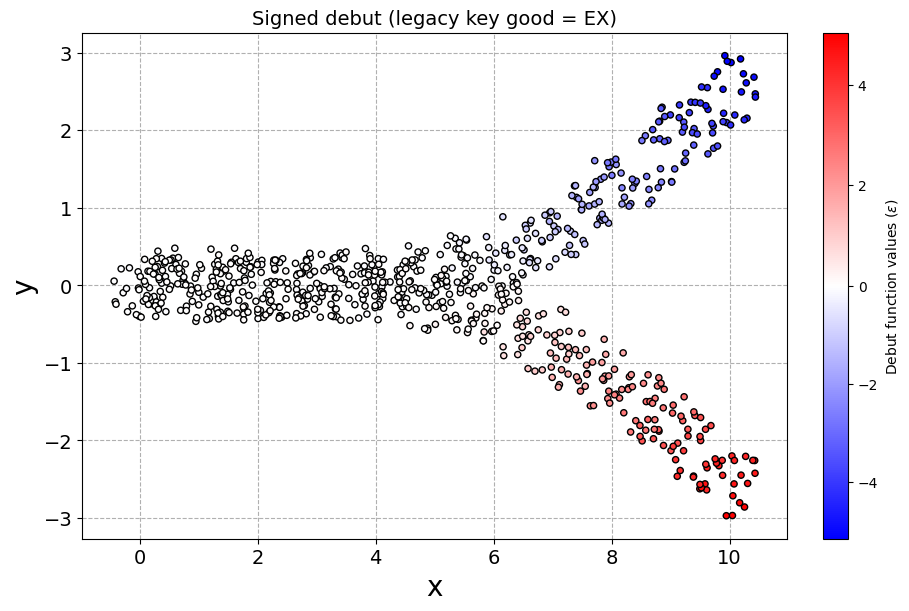

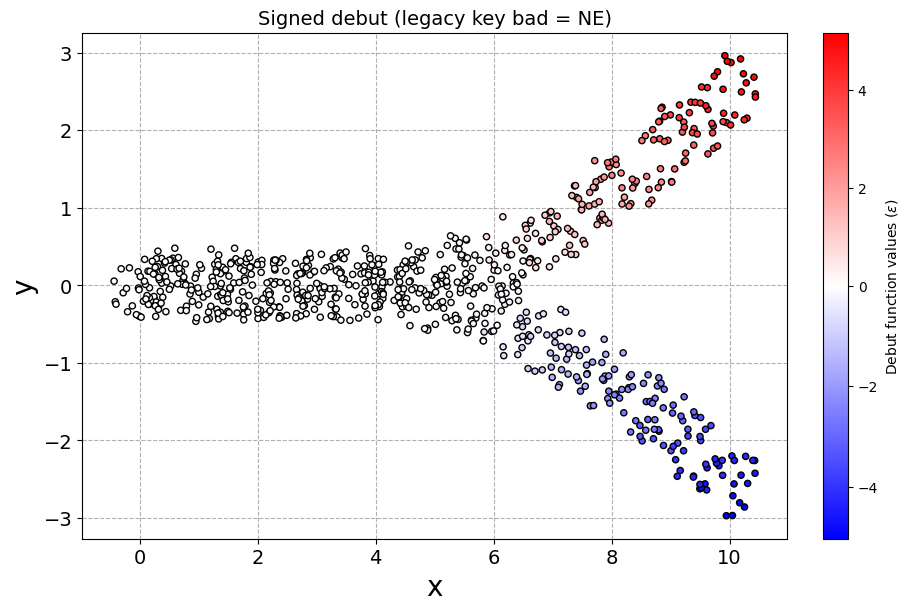

In [14]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="good",
    title="Signed debut (legacy key good = EX)",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_key="bad",
    title="Signed debut (legacy key bad = NE)",
)


## Legacy signed debut-function visualization for $p=1$

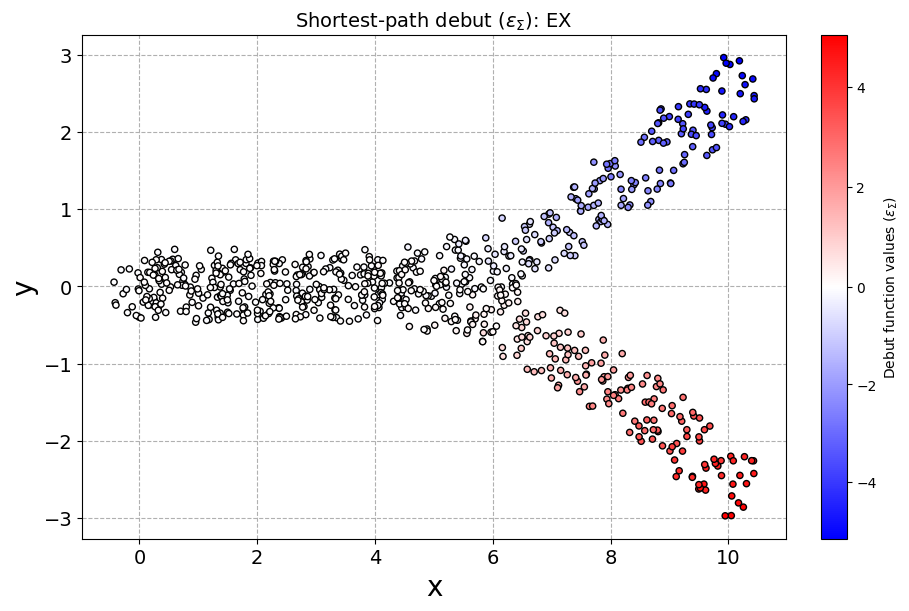

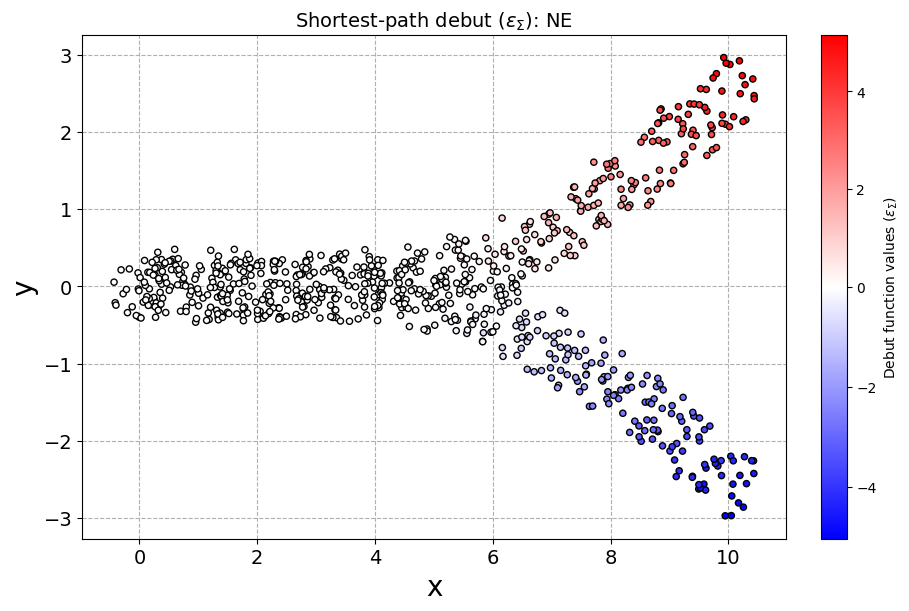

In [15]:
epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="good",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): EX",
)

epsbasin.plot_debut(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_key="bad",
    title=r"Shortest-path debut ($\varepsilon_\Sigma$): NE",
)


## Landscape

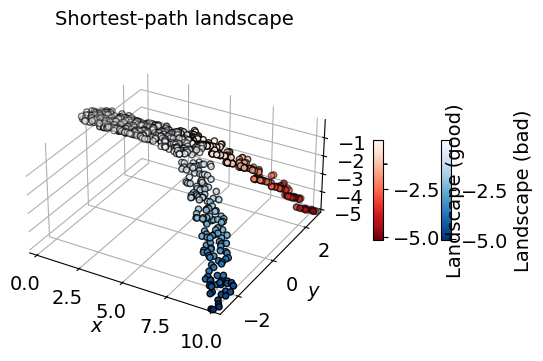

In [16]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title="Shortest-path landscape",
)


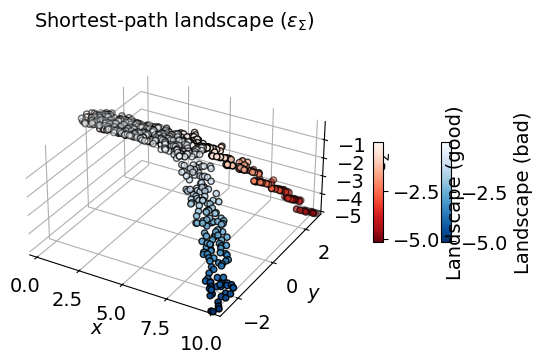

In [17]:
epsbasin.plot_landscape(
    adata,
    eps_key="eps_sum_attracting_basin_sp",
    target_cluster_keys=["good", "bad"],
    figsize=(10, 10),
    show_title=True,
    title=r"Shortest-path landscape ($\varepsilon_\Sigma$)",
)


## Attracting-basin visualization at a selected threshold

This legacy plotting function is retained for comparison. Internally, `good` corresponds to EX and `bad` to NE.

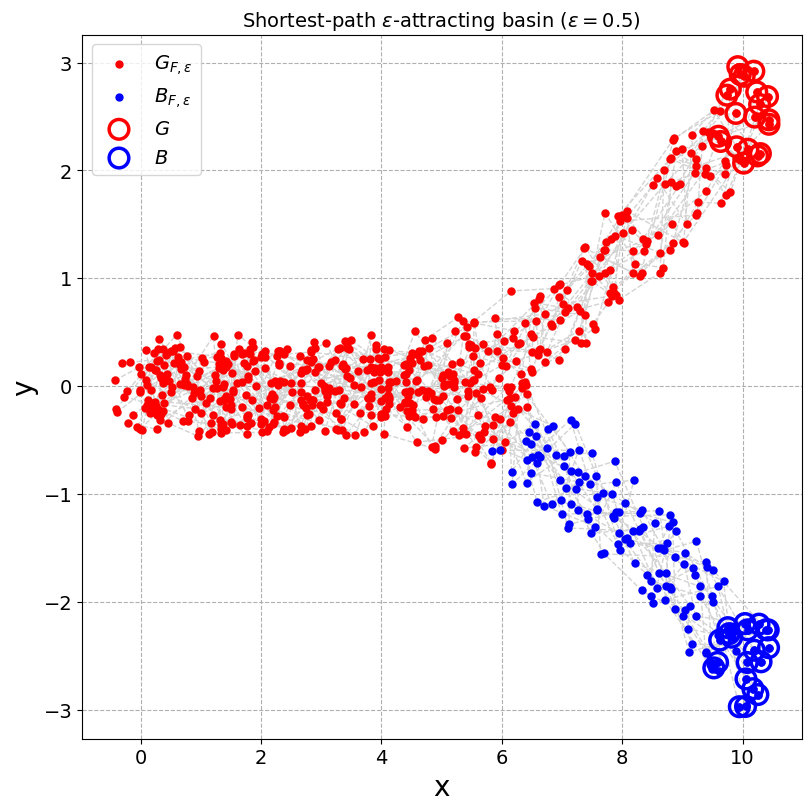

In [18]:
eps_threshold = 0.5

epsbasin.plot_attracting_basin(
    adata,
    eps_key="eps_attracting_basin_sp",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    eps_threshold=eps_threshold,
    figsize=(8, 8),
    title=rf"Shortest-path $\varepsilon$-attracting basin ($\varepsilon={eps_threshold}$)",
)


## Basic consistency checks

In [19]:
# Each observation inherits the natural terminal class of its own sequence.
for sid in adata.obs["seq_id"].unique():
    idx = np.flatnonzero(adata.obs["seq_id"].to_numpy() == sid)
    natural_terminal = adata.obs["cluster"].iloc[idx[-1]]
    assert np.all(adata.obs["terminal_class"].iloc[idx].to_numpy() == natural_terminal)

# The two signed debut functions are complementary under the EX/NE terminal partition (legacy good/bad keys).
np.testing.assert_allclose(
    adata.obs["eps_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_attracting_basin_sp_bad"].to_numpy(),
)
np.testing.assert_allclose(
    adata.obs["eps_sum_attracting_basin_sp_good"].to_numpy(),
    -adata.obs["eps_sum_attracting_basin_sp_bad"].to_numpy(),
)

print("All consistency checks passed.")


All consistency checks passed.


## Leave-one-sequence-out cross-validation

For each `seq_id`, the complete trajectory is removed before constructing the landscape. For a held-out state $x$ at time $t_k$, **only training states at the same `time_idx` are eligible entry states**.

For a non-terminal time,

$$
C_{A,\infty}(t_k,x)
=
\min_n
\max\left\{
 d\bigl(x,x_n(t_k)\bigr),
 C_{A,\infty}\bigl(n,t_{k+1}\bigr)
\right\},
$$

and

$$
C_{A,1}(t_k,x)
=
\min_n
\left[
 d\bigl(x,x_n(t_k)\bigr)
 + C_{A,1}\bigl(n,t_{k+1}\bigr)
\right].
$$

The terminal outcome of the held-out trajectory is used only for scoring the prediction, never for training.  The reported score is $S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$, so positive values predict EX.

In [20]:
def evaluate_external_state(
    adata_train,
    x,
    costs,
    *,
    output_key,
    time_value,
):
    """Evaluate a held-out/background state using the time-layered package helper."""
    return minimum_epsilon_to_good_bad(
        adata_train,
        x,
        costs,
        output_key=output_key,
        time_value=time_value,
    )

In [21]:
def leave_one_sequence_out_cv(
    adata_full,
    *,
    path_cost="max",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    tie_tol=1e-12,
    verbose=True,
):
    """LOSO-CV with strict same-time entry and time-layered dynamics."""
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    seq_values = adata_full.obs[seq_key].to_numpy()
    time_values = adata_full.obs[time_key].to_numpy()
    all_indices = np.arange(adata_full.n_obs)
    seq_ids_unique = list(pd.unique(seq_values))

    if cost_matrix_key in adata_full.uns:
        full_cost = np.asarray(adata_full.uns[cost_matrix_key], dtype=float)
    else:
        from sklearn.metrics import pairwise_distances
        full_cost = pairwise_distances(adata_full.X)

    if full_cost.shape != (adata_full.n_obs, adata_full.n_obs):
        raise ValueError("The full cost matrix has an incompatible shape.")

    rows = []

    for fold, heldout_seq in enumerate(seq_ids_unique, start=1):
        test_indices = all_indices[seq_values == heldout_seq]
        test_indices = test_indices[np.argsort(time_values[test_indices])]
        train_indices = all_indices[seq_values != heldout_seq]

        adata_train = adata_full[train_indices].copy()
        adata_train.uns[cost_matrix_key] = full_cost[
            np.ix_(train_indices, train_indices)
        ].copy()

        if path_cost == "max":
            output_key = "cv_eps_attracting_basin_sp"
            eps_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                time_key=time_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode="adjacent",
                transition_mode="time_layered",
                output_key=output_key,
            )
        else:
            output_key = "cv_eps_sum_attracting_basin_sp"
            eps_sum_attracting_basin_shortest_path(
                adata_train,
                seq_key=seq_key,
                time_key=time_key,
                cluster_key=cluster_key,
                good_cluster_key=good_cluster_key,
                bad_cluster_key=bad_cluster_key,
                cost_matrix_key=cost_matrix_key,
                sequence_edge_mode="adjacent",
                transition_mode="time_layered",
                output_key=output_key,
            )

        true_label = str(adata_full.obs.iloc[test_indices[-1]][cluster_key])
        if true_label not in {good_cluster_key, bad_cluster_key}:
            raise ValueError(
                f"Held-out sequence {heldout_seq!r} does not terminate in "
                f"{good_cluster_key!r} or {bad_cluster_key!r}."
            )

        train_time_values = adata_train.obs[time_key].to_numpy()

        for step, global_index in enumerate(test_indices):
            time_value = time_values[global_index]
            x_query = np.asarray(
                adata_full.X[global_index],
                dtype=float,
            ).reshape(-1)

            # Same-time entry only. The package helper also enforces this, but
            # setting the other entries to inf makes the rule explicit here.
            costs_x_to_train = np.asarray(
                full_cost[global_index, train_indices],
                dtype=float,
            ).copy()
            costs_x_to_train[train_time_values != time_value] = np.inf

            result = evaluate_external_state(
                adata_train,
                x_query,
                costs_x_to_train,
                output_key=output_key,
                time_value=time_value,
            )

            score_good = result.epsilon_bad - result.epsilon_good
            if score_good > tie_tol:
                prediction = good_cluster_key
            elif score_good < -tie_tol:
                prediction = bad_cluster_key
            else:
                prediction = "tie"

            entry_good_local = result.entry_index_good
            entry_bad_local = result.entry_index_bad
            entry_good_global = (
                -1
                if entry_good_local < 0
                else int(train_indices[entry_good_local])
            )
            entry_bad_global = (
                -1
                if entry_bad_local < 0
                else int(train_indices[entry_bad_local])
            )

            true_outcome = "EX" if true_label == good_cluster_key else "NE"
            if prediction == good_cluster_key:
                prediction_outcome = "EX"
            elif prediction == bad_cluster_key:
                prediction_outcome = "NE"
            else:
                prediction_outcome = "tie"

            # Fixed binary rule used for prediction accuracy and calibration:
            # S_p > 0 -> EX, S_p <= 0 -> NE.  Exact ties therefore map to NE.
            prediction_binary = "EX" if score_good > 0.0 else "NE"

            rows.append(
                {
                    "path_cost": path_cost,
                    "seq_id": heldout_seq,
                    "step": step,
                    "time_idx": time_value,
                    "fraction": (
                        0.0
                        if len(test_indices) == 1
                        else step / (len(test_indices) - 1)
                    ),
                    "global_index": int(global_index),
                    "x": float(adata_full.X[global_index, 0]),
                    "y": float(adata_full.X[global_index, 1]),
                    # NEN notation / user-facing columns
                    "true_outcome": true_outcome,
                    "C_EX": float(result.epsilon_good),
                    "C_NE": float(result.epsilon_bad),
                    "S_p": float(score_good),  # C_NE - C_EX
                    "prediction_outcome": prediction_outcome,  # keeps an explicit tie diagnostic
                    "prediction_binary": prediction_binary,
                    "correct_outcome": prediction_outcome == true_outcome,
                    "correct_binary": prediction_binary == true_outcome,
                    # Legacy columns retained for existing downstream code
                    "true_label": true_label,
                    "epsilon_good": result.epsilon_good,
                    "epsilon_bad": result.epsilon_bad,
                    "margin_good": score_good,
                    "prediction": prediction,
                    "correct": prediction == true_label,
                    "entry_good_global_index": entry_good_global,
                    "entry_bad_global_index": entry_bad_global,
                }
            )

        if verbose:
            print(
                f"[{fold:02d}/{len(seq_ids_unique):02d}] "
                f"held out seq_id={heldout_seq!r}"
            )

    return pd.DataFrame(rows)

### Run LOSO-CV for ordinary $\varepsilon$

Each training landscape is recomputed with `transition_mode="time_layered"`. The held-out query can enter only the training states at its own `time_idx`.

In [22]:
cv_eps = leave_one_sequence_out_cv(
    adata,
    path_cost="max",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    verbose=True,
)

cv_eps.head(10)

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,path_cost,seq_id,step,time_idx,fraction,global_index,x,y,true_outcome,C_EX,...,correct_outcome,correct_binary,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index
0,max,0,0,0,0.000000,0,0.392749,0.070632,EX,0.045768,...,True,True,good,0.045768,0.048356,0.002588,good,True,160,160
1,max,0,1,1,0.052632,1,0.710780,0.182812,EX,0.043444,...,False,False,good,0.043444,0.043444,0.000000,tie,False,101,101
2,max,0,2,2,0.105263,2,1.004222,-0.088817,EX,0.059007,...,False,False,good,0.059007,0.059007,0.000000,tie,False,782,782
3,max,0,3,3,0.157895,3,1.540252,-0.050838,EX,0.021054,...,True,True,good,0.021054,0.047629,0.026575,good,True,263,263
4,max,0,4,4,0.210526,4,1.767755,-0.296941,EX,0.035485,...,True,True,good,0.035485,0.051179,0.015694,good,True,164,164
5,max,0,5,5,0.263158,5,2.275895,0.325172,EX,0.035352,...,True,True,good,0.035352,0.043361,0.008009,good,True,385,505
6,max,0,6,6,0.315789,6,3.547269,0.008826,EX,0.146134,...,False,False,good,0.146134,0.146134,0.000000,tie,False,546,546
7,max,0,7,7,0.368421,7,4.108171,-0.017590,EX,0.104761,...,False,False,good,0.104761,0.104761,0.000000,tie,False,27,27
8,max,0,8,8,0.421053,8,4.065269,-0.273527,EX,0.030749,...,True,True,good,0.030749,0.073283,0.042534,good,True,108,588
9,max,0,9,9,0.473684,9,4.453780,-0.275514,EX,0.121955,...,False,False,good,0.121955,0.070527,-0.051428,bad,False,209,509


### Terminal-state prediction accuracy

The last state of each held-out trajectory is one independent terminal prediction. The fixed rule used for prediction accuracy is **EX if $S_p>0$, NE if $S_p\le0$**. Exact ties are therefore assigned to NE, while `prediction_outcome == "tie"` is retained only as a separate diagnostic.

In [23]:
terminal_cv = (
    cv_eps.sort_values(["seq_id", "step"])
    .groupby("seq_id", sort=False)
    .tail(1)
    .reset_index(drop=True)
)

accuracy_binary = terminal_cv["correct_binary"].mean()
resolved = terminal_cv["prediction_outcome"] != "tie"
accuracy_resolved = (
    terminal_cv.loc[resolved, "correct_outcome"].mean() if resolved.any() else np.nan
)
tie_rate = (~resolved).mean()

print(f"terminal binary accuracy (tie -> NE): {accuracy_binary:.3f}")
print(f"terminal accuracy (resolved only):    {accuracy_resolved:.3f}")
print(f"terminal exact-tie rate:              {tie_rate:.3f}")

display(terminal_cv[[
    "seq_id",
    "true_outcome",
    "C_EX",
    "C_NE",
    "S_p",
    "prediction_binary",
    "prediction_outcome",
    "correct_binary",
]])

terminal binary accuracy (tie -> NE): 1.000
terminal accuracy (resolved only):    1.000
terminal exact-tie rate:              0.000


,seq_id,true_outcome,C_EX,C_NE,S_p,prediction_binary,prediction_outcome,correct_binary
0,0,EX,0.079574,4.958530,4.878957,EX,EX,True
1,1,EX,0.225839,4.729932,4.504093,EX,EX,True
2,2,EX,0.150477,4.891290,4.740812,EX,EX,True
3,3,EX,0.126064,4.815690,4.689626,EX,EX,True
4,4,EX,0.060187,4.486144,4.425957,EX,EX,True
5,5,EX,0.041265,4.676571,4.635306,EX,EX,True
6,6,EX,0.041265,4.635432,4.594168,EX,EX,True
7,7,EX,0.051427,4.360574,4.309148,EX,EX,True
8,8,EX,0.066509,5.071723,5.005214,EX,EX,True
9,9,EX,0.079574,4.905758,4.826184,EX,EX,True


### Time-dependent outcome commitment surfaces $S_p(t,x)$

Because the system is non-autonomous, both the minimum perturbation cost fields
and the commitment score are time dependent.  At a selected time layer,

$$
\boxed{S_p(t,x)=C_{p,\mathrm{NE}}(t,x)-C_{p,\mathrm{EX}}(t,x)}.
$$

Therefore $S_p>0$ favors EX, $S_p<0$ favors NE, and the zero contour is the
neutral commitment boundary.  Only ensemble states at the same time are
admissible switching targets.

max: time-layered recurrence max error = 0.000e+00
sum: time-layered recurrence max error = 0.000e+00
eps_attracting_basin_sp: 12 background-query checks passed at time 18.
eps_sum_attracting_basin_sp: 12 background-query checks passed at time 18.
surface time_idx = 18
S_inf range = [-4.2499, 4.2305]
S_1 range   = [-4.3315, 4.2372]


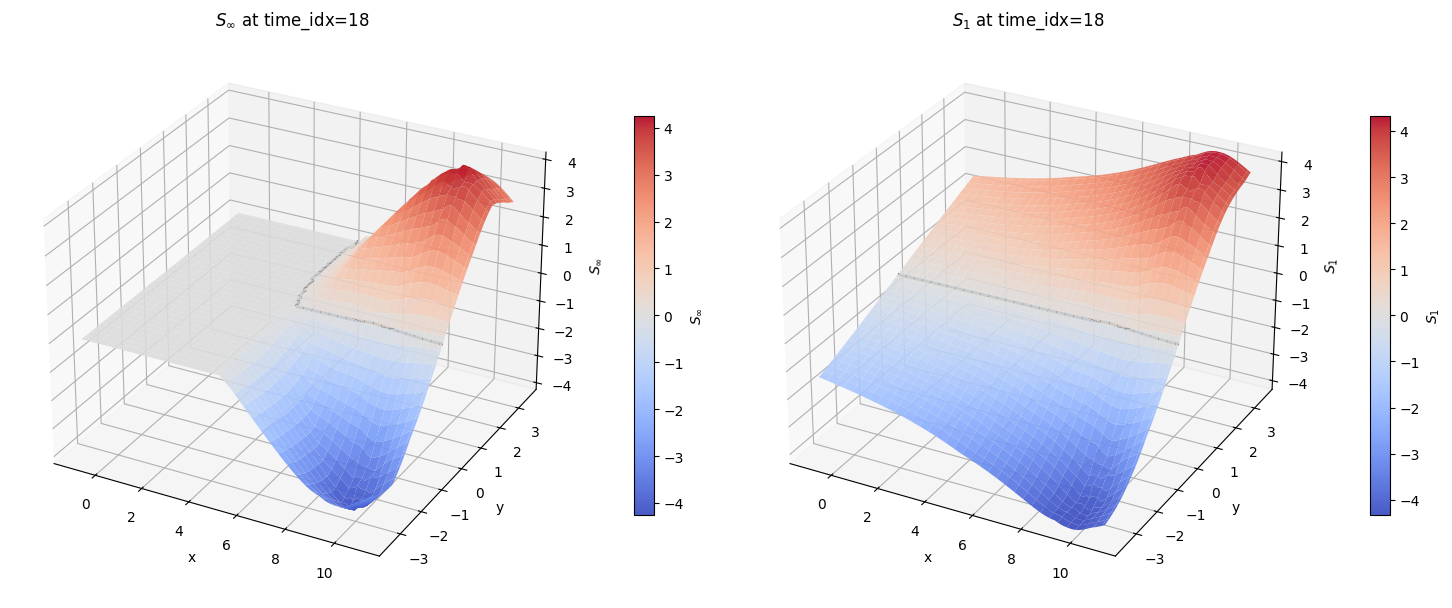

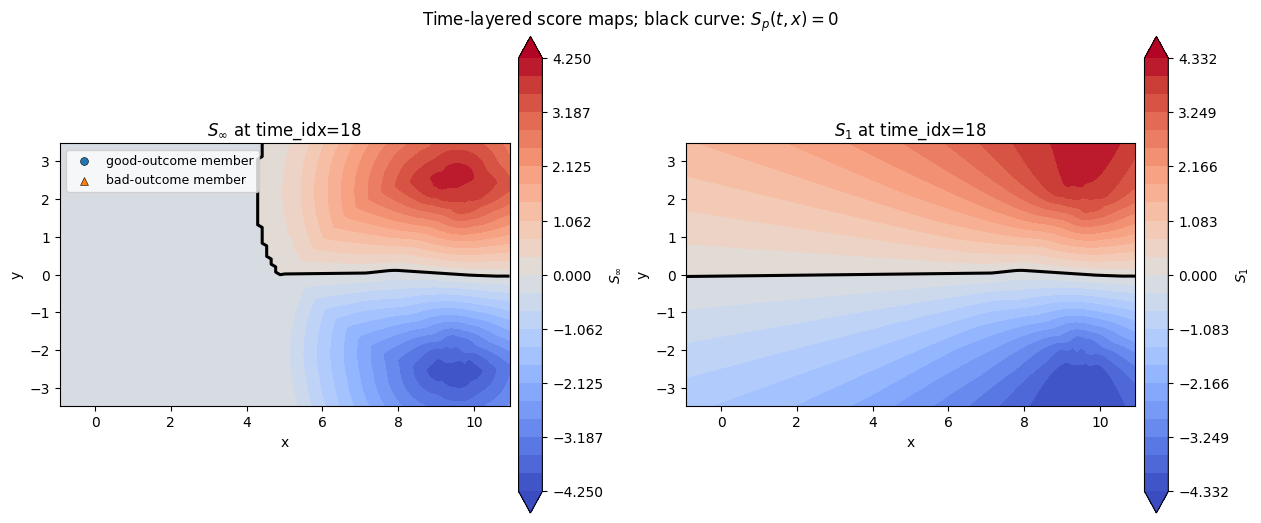

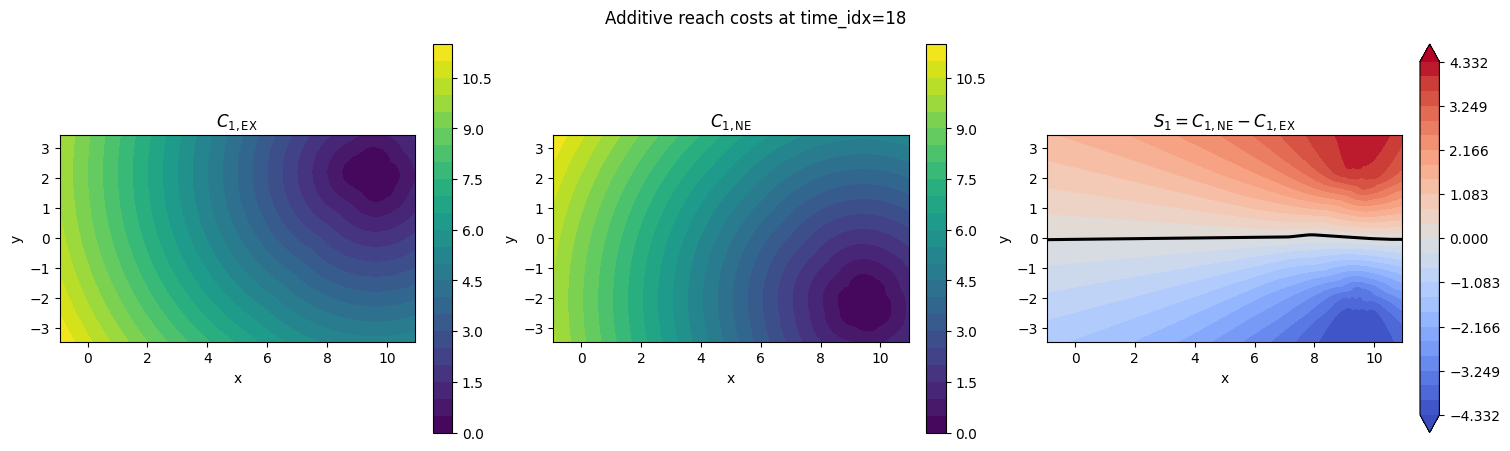

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

SURFACE_TIME_IDX = int(adata.obs["time_idx"].max()) - 1
SURFACE_NX = 101
SURFACE_NY = 101
SAVE_SCORE_SURFACE_FIGURES = False
SCORE_SURFACE_OUTPUT_DIR = Path("figures")
if SAVE_SCORE_SURFACE_FIGURES:
    SCORE_SURFACE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _finite_symmetric_limit(values):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 1.0
    value = float(np.max(np.abs(finite)))
    return 1.0 if value == 0.0 else value


def _time_layer_indices(adata_obj, time_value):
    seq_values = adata_obj.obs["seq_id"].to_numpy()
    time_values = adata_obj.obs["time_idx"].to_numpy()
    seq_ids_here = list(pd.unique(seq_values))
    unique_times = np.sort(pd.unique(time_values))

    matches = np.flatnonzero(unique_times == time_value)
    if matches.size != 1:
        raise ValueError(f"time_idx={time_value!r} is not in the data.")
    t_pos = int(matches[0])

    current = []
    following = []
    for sid in seq_ids_here:
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        current_match = idx[time_values[idx] == time_value]
        if current_match.size != 1:
            raise ValueError(
                f"seq_id={sid!r} has {current_match.size} states at time {time_value}."
            )
        current.append(int(current_match[0]))
        if t_pos < unique_times.size - 1:
            next_time = unique_times[t_pos + 1]
            next_match = idx[time_values[idx] == next_time]
            if next_match.size != 1:
                raise ValueError(
                    f"seq_id={sid!r} has {next_match.size} states at time {next_time}."
                )
            following.append(int(next_match[0]))

    return (
        np.asarray(current, dtype=int),
        None if not following else np.asarray(following, dtype=int),
        unique_times,
    )


def compute_time_layered_score_surface(
    adata_obj,
    *,
    time_value,
    distance_good_key,
    distance_bad_key,
    path_cost,
    score_label,
    nx=SURFACE_NX,
    ny=SURFACE_NY,
    pad_x=0.5,
    pad_y=0.5,
):
    """Evaluate S_p(t,x) using only the selected time layer."""
    if path_cost not in {"max", "sum"}:
        raise ValueError("path_cost must be 'max' or 'sum'.")

    X = np.asarray(adata_obj.X, dtype=float)
    current, following, unique_times = _time_layer_indices(
        adata_obj,
        time_value,
    )
    X_current = X[current]

    x_grid = np.linspace(X[:, 0].min() - pad_x, X[:, 0].max() + pad_x, nx)
    y_grid = np.linspace(X[:, 1].min() - pad_y, X[:, 1].max() + pad_y, ny)
    XX, YY = np.meshgrid(x_grid, y_grid)
    points = np.column_stack([XX.ravel(), YY.ravel()])
    entry = np.linalg.norm(
        points[:, None, :] - X_current[None, :, :],
        axis=2,
    )

    if following is None:
        labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
        good_cols = np.flatnonzero(labels == "good")
        bad_cols = np.flatnonzero(labels == "bad")
        cost_good = np.min(entry[:, good_cols], axis=1)
        cost_bad = np.min(entry[:, bad_cols], axis=1)
    else:
        future_good = adata_obj.obs.iloc[following][
            distance_good_key
        ].to_numpy(dtype=float)
        future_bad = adata_obj.obs.iloc[following][
            distance_bad_key
        ].to_numpy(dtype=float)

        if path_cost == "max":
            cost_good = np.min(
                np.maximum(entry, future_good[None, :]),
                axis=1,
            )
            cost_bad = np.min(
                np.maximum(entry, future_bad[None, :]),
                axis=1,
            )
        else:
            cost_good = np.min(entry + future_good[None, :], axis=1)
            cost_bad = np.min(entry + future_bad[None, :], axis=1)

    score = cost_bad - cost_good
    return {
        "label": score_label,
        "time_value": time_value,
        "X": XX,
        "Y": YY,
        "score": score.reshape(YY.shape),
        "cost_good": cost_good.reshape(YY.shape),   # legacy = EX
        "cost_bad": cost_bad.reshape(YY.shape),     # legacy = NE
        "cost_EX": cost_good.reshape(YY.shape),
        "cost_NE": cost_bad.reshape(YY.shape),
        "current_indices": current,
        "xlim": (x_grid[0], x_grid[-1]),
        "ylim": (y_grid[0], y_grid[-1]),
    }


def validate_time_layered_recurrence(
    adata_obj,
    *,
    distance_good_key,
    distance_bad_key,
    path_cost,
    atol=1e-10,
):
    """Check every time layer against the time-layered Bellman recursion."""
    X = np.asarray(adata_obj.X, dtype=float)
    full_cost = np.asarray(adata_obj.uns["cost_matrix"], dtype=float)
    times = np.sort(pd.unique(adata_obj.obs["time_idx"]))
    d_good = adata_obj.obs[distance_good_key].to_numpy(dtype=float)
    d_bad = adata_obj.obs[distance_bad_key].to_numpy(dtype=float)

    max_error = 0.0
    for t_pos, time_value in enumerate(times):
        current, following, _ = _time_layer_indices(adata_obj, time_value)
        switch = full_cost[np.ix_(current, current)]

        if following is None:
            labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
            good_targets = current[labels == "good"]
            bad_targets = current[labels == "bad"]
            expected_good = np.min(
                full_cost[np.ix_(current, good_targets)],
                axis=1,
            )
            expected_bad = np.min(
                full_cost[np.ix_(current, bad_targets)],
                axis=1,
            )
        else:
            if path_cost == "max":
                expected_good = np.min(
                    np.maximum(switch, d_good[following][None, :]),
                    axis=1,
                )
                expected_bad = np.min(
                    np.maximum(switch, d_bad[following][None, :]),
                    axis=1,
                )
            else:
                expected_good = np.min(
                    switch + d_good[following][None, :],
                    axis=1,
                )
                expected_bad = np.min(
                    switch + d_bad[following][None, :],
                    axis=1,
                )

        max_error = max(
            max_error,
            float(np.max(np.abs(expected_good - d_good[current]))),
            float(np.max(np.abs(expected_bad - d_bad[current]))),
        )

    print(f"{path_cost}: time-layered recurrence max error = {max_error:.3e}")
    if max_error > atol:
        raise AssertionError(
            f"{path_cost} distances do not satisfy the time-layered recurrence."
        )


def validate_background_queries(
    adata_obj,
    *,
    time_value,
    output_key,
    surface,
    n_checks=12,
    random_state=0,
    atol=1e-10,
):
    """Compare direct surface evaluation with the package external-state helper."""
    rng = np.random.default_rng(random_state)
    current = surface["current_indices"]
    X_current = np.asarray(adata_obj.X[current], dtype=float)

    xmin, xmax = surface["xlim"]
    ymin, ymax = surface["ylim"]
    points = np.column_stack([
        rng.uniform(xmin, xmax, n_checks),
        rng.uniform(ymin, ymax, n_checks),
    ])

    for point in points:
        costs = np.full(adata_obj.n_obs, np.inf, dtype=float)
        costs[current] = np.linalg.norm(
            X_current - point[None, :],
            axis=1,
        )
        result = minimum_epsilon_to_good_bad(
            adata_obj,
            point,
            costs,
            output_key=output_key,
            time_value=time_value,
        )

        # Recompute directly at the point using the same selected layer.
        # This keeps the validation independent of grid interpolation.
        following = _time_layer_indices(adata_obj, time_value)[1]
        entry = costs[current]
        if following is None:
            labels = adata_obj.obs.iloc[current]["cluster"].astype(str).to_numpy()
            direct_good = np.min(entry[labels == "good"])
            direct_bad = np.min(entry[labels == "bad"])
        else:
            params = adata_obj.uns[f"{output_key}_params"]
            path_cost = params["path_cost"]
            d_good = np.maximum(
                adata_obj.obs[f"{output_key}_good"].to_numpy(dtype=float),
                0.0,
            )[following]
            d_bad = np.maximum(
                adata_obj.obs[f"{output_key}_bad"].to_numpy(dtype=float),
                0.0,
            )[following]
            if path_cost == "max":
                direct_good = np.min(np.maximum(entry, d_good))
                direct_bad = np.min(np.maximum(entry, d_bad))
            else:
                direct_good = np.min(entry + d_good)
                direct_bad = np.min(entry + d_bad)

        if not (
            np.isclose(direct_good, result.epsilon_good, atol=atol, rtol=0.0)
            and np.isclose(direct_bad, result.epsilon_bad, atol=atol, rtol=0.0)
        ):
            raise AssertionError("Background query does not match package helper.")

    print(f"{output_key}: {n_checks} background-query checks passed at time {time_value}.")


def _outcome_for_current_states(adata_obj, indices):
    terminal_class = adata_obj.obs.iloc[indices]["terminal_class"].astype(str).to_numpy()
    return np.where(terminal_class == EX_CLUSTER_KEY, "EX", "NE")


def plot_score_map(ax, surface, *, vabs, title, show_legend=False):
    Xg, Yg, Zg = surface["X"], surface["Y"], surface["score"]
    levels = np.linspace(-vabs, vabs, 25)
    image = ax.contourf(
        Xg,
        Yg,
        Zg,
        levels=levels,
        cmap="coolwarm",
        vmin=-vabs,
        vmax=vabs,
        extend="both",
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        levels=[0.0],
        colors="black",
        linewidths=2.2,
    )

    current = surface["current_indices"]
    outcomes = _outcome_for_current_states(adata, current)
    for label, marker in [("good", "o"), ("bad", "^")]:
        pts = np.asarray(adata.X[current[outcomes == label]], dtype=float)
        ax.scatter(
            pts[:, 0],
            pts[:, 1],
            s=32,
            marker=marker,
            edgecolor="black",
            linewidth=0.4,
            label=f"{label}-outcome member",
            zorder=5,
        )

    ax.set_xlim(*surface["xlim"])
    ax.set_ylim(*surface["ylim"])
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    if show_legend:
        ax.legend(frameon=True, fontsize=9, loc="upper left")
    return image


def plot_score_surface_3d(ax, surface, *, vabs, zlabel):
    Xg, Yg, Zg = surface["X"], surface["Y"], surface["score"]
    surf = ax.plot_surface(
        Xg,
        Yg,
        Zg,
        cmap="coolwarm",
        vmin=-vabs,
        vmax=vabs,
        linewidth=0,
        antialiased=True,
        alpha=0.92,
    )
    ax.contour(
        Xg,
        Yg,
        Zg,
        levels=[0.0],
        colors="black",
        linewidths=2.0,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel(zlabel)
    ax.set_zlim(-vabs, vabs)
    ax.view_init(elev=28, azim=-62)
    return surf


# Validate the dynamic programming values first.
validate_time_layered_recurrence(
    adata,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
)
validate_time_layered_recurrence(
    adata,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
)

surface_inf = compute_time_layered_score_surface(
    adata,
    time_value=SURFACE_TIME_IDX,
    distance_good_key="eps_distance_sp_good",
    distance_bad_key="eps_distance_sp_bad",
    path_cost="max",
    score_label=r"$S_\infty(t,x)=C_{\infty,\mathrm{NE}}-C_{\infty,\mathrm{EX}}$",
)
surface_one = compute_time_layered_score_surface(
    adata,
    time_value=SURFACE_TIME_IDX,
    distance_good_key="eps_sum_distance_sp_good",
    distance_bad_key="eps_sum_distance_sp_bad",
    path_cost="sum",
    score_label=r"$S_1(t,x)=C_{1,\mathrm{NE}}-C_{1,\mathrm{EX}}$",
)

validate_background_queries(
    adata,
    time_value=SURFACE_TIME_IDX,
    output_key="eps_attracting_basin_sp",
    surface=surface_inf,
)
validate_background_queries(
    adata,
    time_value=SURFACE_TIME_IDX,
    output_key="eps_sum_attracting_basin_sp",
    surface=surface_one,
)

vabs_inf = _finite_symmetric_limit(surface_inf["score"])
vabs_one = _finite_symmetric_limit(surface_one["score"])
print(
    f"surface time_idx = {SURFACE_TIME_IDX}\n"
    f"S_inf range = [{np.nanmin(surface_inf['score']):.4f}, "
    f"{np.nanmax(surface_inf['score']):.4f}]\n"
    f"S_1 range   = [{np.nanmin(surface_one['score']):.4f}, "
    f"{np.nanmax(surface_one['score']):.4f}]"
)

# 1) 3D surfaces
fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
s1 = plot_score_surface_3d(ax1, surface_inf, vabs=vabs_inf, zlabel=r"$S_\infty$")
s2 = plot_score_surface_3d(ax2, surface_one, vabs=vabs_one, zlabel=r"$S_1$")
ax1.set_title(rf"$S_\infty$ at time_idx={SURFACE_TIME_IDX}")
ax2.set_title(rf"$S_1$ at time_idx={SURFACE_TIME_IDX}")
fig.colorbar(s1, ax=ax1, shrink=0.7, pad=0.08, label=r"$S_\infty$")
fig.colorbar(s2, ax=ax2, shrink=0.7, pad=0.08, label=r"$S_1$")
fig.tight_layout()
plt.show()

# 2) Publication-oriented 2D score maps
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1), constrained_layout=True)
im1 = plot_score_map(
    axes[0],
    surface_inf,
    vabs=vabs_inf,
    title=rf"$S_\infty$ at time_idx={SURFACE_TIME_IDX}",
    show_legend=True,
)
im2 = plot_score_map(
    axes[1],
    surface_one,
    vabs=vabs_one,
    title=rf"$S_1$ at time_idx={SURFACE_TIME_IDX}",
)
fig.colorbar(im1, ax=axes[0], shrink=0.95, pad=0.02, label=r"$S_\infty$")
fig.colorbar(im2, ax=axes[1], shrink=0.95, pad=0.02, label=r"$S_1$")
fig.suptitle(r"Time-layered score maps; black curve: $S_p(t,x)=0$", y=1.02)
if SAVE_SCORE_SURFACE_FIGURES:
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_time_layered.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCORE_SURFACE_OUTPUT_DIR / "score_surface_time_layered.pdf",
        bbox_inches="tight",
    )
plt.show()

# 3) Diagnostic decomposition for p=1: C_EX, C_NE, and S_1
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.4), constrained_layout=True)
cg = axes[0].contourf(surface_one["X"], surface_one["Y"], surface_one["cost_good"], levels=25)
cb = axes[1].contourf(surface_one["X"], surface_one["Y"], surface_one["cost_bad"], levels=25)
ss = plot_score_map(axes[2], surface_one, vabs=vabs_one, title=r"$S_1=C_{1,\mathrm{NE}}-C_{1,\mathrm{EX}}$")
axes[0].set_title(r"$C_{1,\mathrm{EX}}$")
axes[1].set_title(r"$C_{1,\mathrm{NE}}$")
for ax in axes[:2]:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
fig.colorbar(cg, ax=axes[0], shrink=0.9)
fig.colorbar(cb, ax=axes[1], shrink=0.9)
fig.colorbar(ss, ax=axes[2], shrink=0.9)
fig.suptitle(rf"Additive reach costs at time_idx={SURFACE_TIME_IDX}", y=1.02)
plt.show()

### Leave-one-sequence-out $S_p(t)$ heatmaps and time-resolved prediction accuracy

For each sequence, the **entire trajectory is removed** from the training
ensemble.  The time-layered fields are reconstructed from the remaining
sequences and

$$
\boxed{S_p(t,x)=C_{p,\mathrm{NE}}(t,x)-C_{p,\mathrm{EX}}(t,x)}
$$

is evaluated at every held-out state.  Every pixel is therefore strictly
out-of-sample with respect to its sequence.

The binary prediction rule is

$$
\widehat Y(t)=
\begin{cases}
\mathrm{EX}, & S_p(t)>0,\\
\mathrm{NE}, & S_p(t)\le0.
\end{cases}
$$

For visualization only, rows are ordered by the true terminal outcome with EX
above NE; this ordering never enters fitting or prediction.

[01/40] held out seq_id=np.int64(0)
[02/40] held out seq_id=np.int64(1)
[03/40] held out seq_id=np.int64(2)
[04/40] held out seq_id=np.int64(3)
[05/40] held out seq_id=np.int64(4)
[06/40] held out seq_id=np.int64(5)
[07/40] held out seq_id=np.int64(6)
[08/40] held out seq_id=np.int64(7)
[09/40] held out seq_id=np.int64(8)
[10/40] held out seq_id=np.int64(9)
[11/40] held out seq_id=np.int64(10)
[12/40] held out seq_id=np.int64(11)
[13/40] held out seq_id=np.int64(12)
[14/40] held out seq_id=np.int64(13)
[15/40] held out seq_id=np.int64(14)
[16/40] held out seq_id=np.int64(15)
[17/40] held out seq_id=np.int64(16)
[18/40] held out seq_id=np.int64(17)
[19/40] held out seq_id=np.int64(18)
[20/40] held out seq_id=np.int64(19)
[21/40] held out seq_id=np.int64(20)
[22/40] held out seq_id=np.int64(21)
[23/40] held out seq_id=np.int64(22)
[24/40] held out seq_id=np.int64(23)
[25/40] held out seq_id=np.int64(24)
[26/40] held out seq_id=np.int64(25)
[27/40] held out seq_id=np.int64(26)
[28/40] hel

,time_idx,accuracy_Linf,accuracy_L1
0,0,0.525,0.650
1,1,0.500,0.450
2,2,0.625,0.525
3,3,0.500,0.525
4,4,0.475,0.450
5,5,0.475,0.325
6,6,0.475,0.675
7,7,0.525,0.550
8,8,0.650,0.625
9,9,0.425,0.475


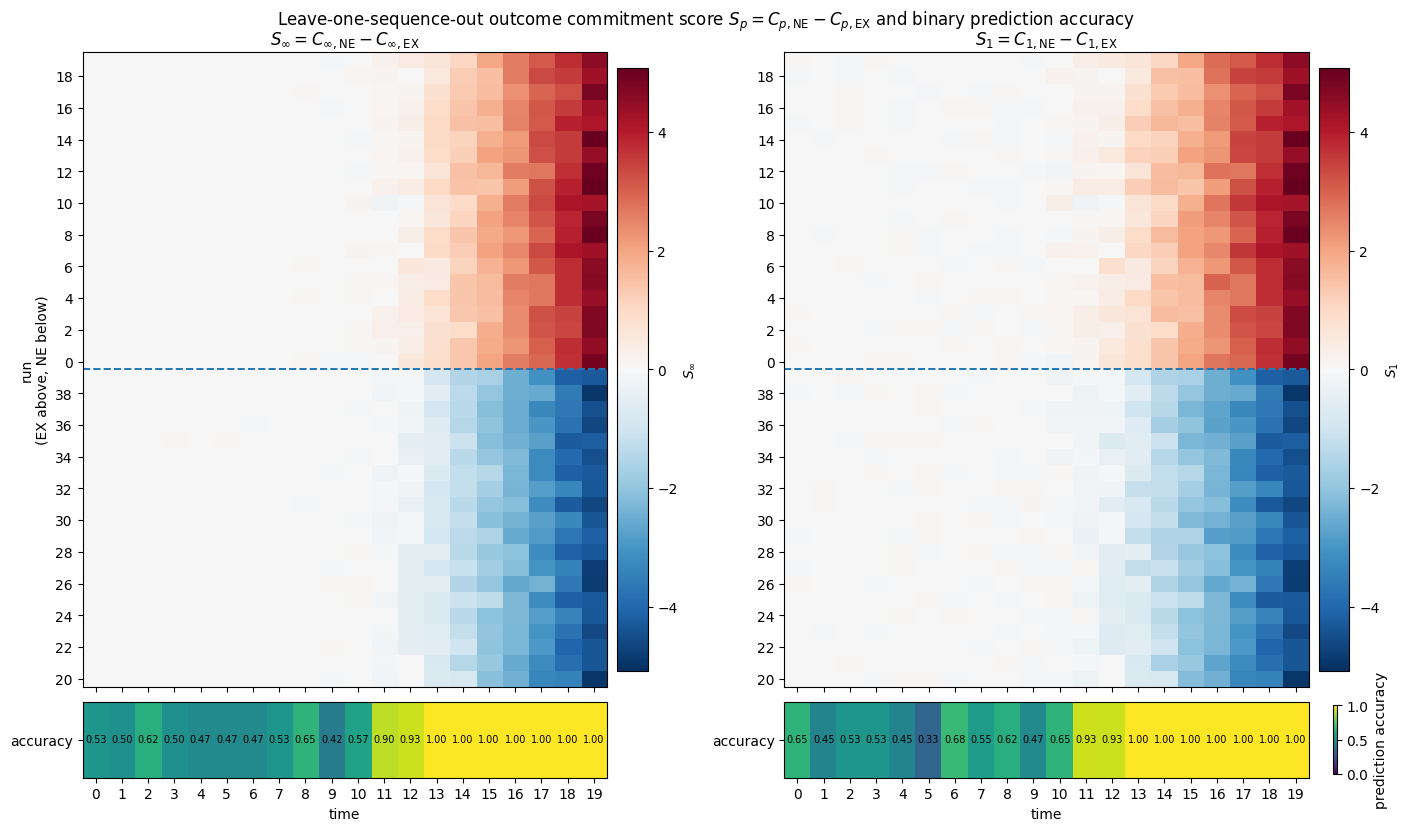

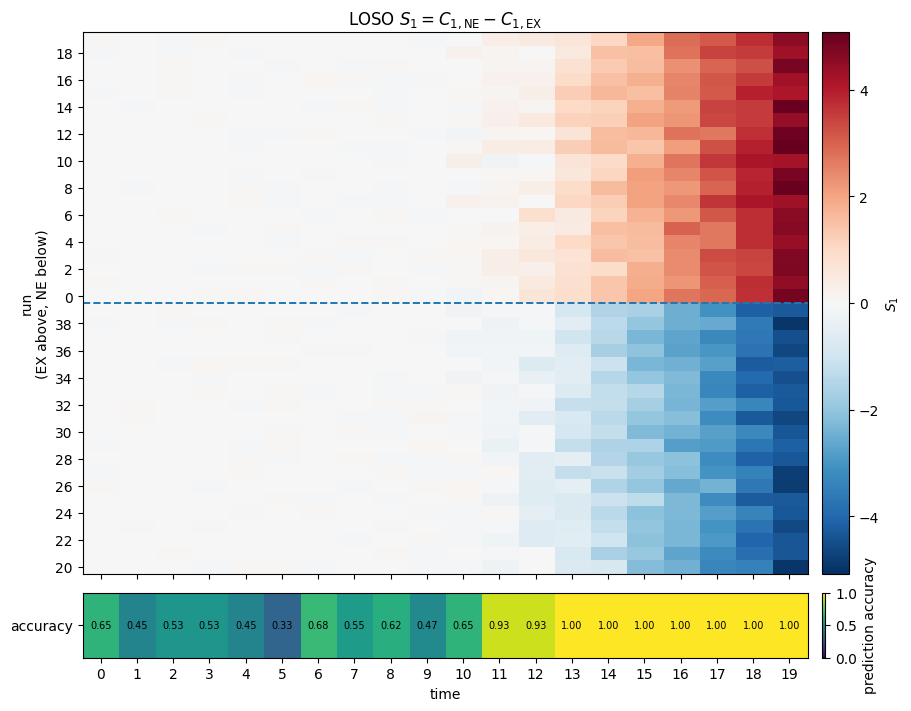

In [25]:
# ------------------------------------------------------------------
# Compute LOSO-CV S_p(t) for BOTH path costs and display:
#   1) run x time score heatmap
#   2) one-row time-resolved prediction-accuracy heatmap
#
# cv_eps (p=infinity) has already been computed above.
# ------------------------------------------------------------------

# p = 1 LOSO-CV
cv_eps_sum = leave_one_sequence_out_cv(
    adata,
    path_cost="sum",
    seq_key="seq_id",
    time_key="time_idx",
    cluster_key="cluster",
    good_cluster_key="good",
    bad_cluster_key="bad",
    cost_matrix_key="cost_matrix",
    verbose=True,
)


def loso_score_matrix(
    cv_frame,
    *,
    seq_key="seq_id",
    time_key="time_idx",
    score_key="S_p",
):
    """
    Convert LOSO output into a run x time matrix of
    S_p = C_p,NE - C_p,EX.
    """
    seq_ids = np.sort(pd.unique(cv_frame[seq_key]))
    time_values = np.sort(pd.unique(cv_frame[time_key]))

    matrix = (
        cv_frame
        .pivot(index=seq_key, columns=time_key, values=score_key)
        .reindex(index=seq_ids, columns=time_values)
        .to_numpy(dtype=float)
    )

    if matrix.shape != (len(seq_ids), len(time_values)):
        raise ValueError(
            "Unexpected LOSO score-matrix shape: "
            f"{matrix.shape}; expected {(len(seq_ids), len(time_values))}."
        )
    if not np.isfinite(matrix).all():
        missing = np.argwhere(~np.isfinite(matrix))
        raise ValueError(
            "The LOSO score heatmap contains missing/non-finite values. "
            f"First locations: {missing[:10].tolist()}"
        )

    outcome = (
        cv_frame[[seq_key, "true_outcome"]]
        .drop_duplicates(subset=[seq_key])
        .set_index(seq_key)
        .reindex(seq_ids)["true_outcome"]
        .astype(str)
        .to_numpy()
    )

    return seq_ids, time_values, matrix, outcome


def binary_accuracy_by_time(score_matrix, outcomes):
    """
    Prediction rule:
        S_p > 0  -> EX
        S_p <= 0 -> NE

    Returns one accuracy value for each time.
    """
    score_matrix = np.asarray(score_matrix, dtype=float)
    outcomes = np.asarray(outcomes, dtype=str)

    true_extreme = (outcomes == "EX")[:, None]
    predicted_extreme = score_matrix > 0.0

    return np.mean(
        predicted_extreme == true_extreme,
        axis=0,
    )


def symmetric_limit(matrix, quantile=None):
    """Return a symmetric plotting limit around S_p=0."""
    values = np.abs(np.asarray(matrix, dtype=float))
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 1.0

    if quantile is None:
        vmax = float(np.max(values))
    else:
        vmax = float(np.quantile(values, quantile))

    return 1.0 if vmax == 0.0 else vmax


# ----------------------------------------------------------
# Build score matrices.
# ----------------------------------------------------------
seq_inf, time_inf, score_inf, outcome_inf = loso_score_matrix(cv_eps)
seq_one, time_one, score_one, outcome_one = loso_score_matrix(cv_eps_sum)

if not np.array_equal(seq_inf, seq_one):
    raise ValueError("p=infinity and p=1 LOSO runs are not aligned.")
if not np.array_equal(time_inf, time_one):
    raise ValueError("p=infinity and p=1 LOSO time grids are not aligned.")
if not np.array_equal(outcome_inf, outcome_one):
    raise ValueError("p=infinity and p=1 terminal outcomes are not aligned.")

loso_seq_ids = seq_inf
loso_time_values = time_inf
loso_outcomes = outcome_inf

# ----------------------------------------------------------
# Prediction accuracy at every time.
#
# Important: this is computed BEFORE display reordering.
# The ordering therefore has no effect on prediction accuracy.
# ----------------------------------------------------------
accuracy_inf = binary_accuracy_by_time(
    score_inf,
    loso_outcomes,
)
accuracy_one = binary_accuracy_by_time(
    score_one,
    loso_outcomes,
)

accuracy_table = pd.DataFrame(
    {
        "time_idx": loso_time_values,
        "accuracy_Linf": accuracy_inf,
        "accuracy_L1": accuracy_one,
    }
)

display(accuracy_table)


# ----------------------------------------------------------
# Display ordering: NE at the bottom, EX at the top.
#
# With origin="lower", the first matrix row is drawn at the bottom.
# Therefore we put NE rows first and EX rows last.
#
# This uses true outcomes ONLY to arrange rows visually.
# It does not affect fitting, held-out S_p, or accuracy.
# ----------------------------------------------------------
ne_positions = np.flatnonzero(loso_outcomes == "NE")
ex_positions = np.flatnonzero(loso_outcomes == "EX")
display_order = np.r_[ne_positions, ex_positions]

display_seq_ids = loso_seq_ids[display_order]
display_outcomes = loso_outcomes[display_order]
display_score_inf = score_inf[display_order]
display_score_one = score_one[display_order]

n_ne_display = len(ne_positions)
n_ex_display = len(ex_positions)
outcome_boundary_y = n_ne_display - 0.5

# Independent numerical ranges because L_infinity and L_1 have
# different cost scales.
vmax_inf = symmetric_limit(score_inf)
vmax_one = symmetric_limit(score_one)

# Thin y ticks if many runs are present.
if len(display_seq_ids) <= 30:
    ytick_pos = np.arange(len(display_seq_ids))
else:
    step_y = max(1, len(display_seq_ids) // 20)
    ytick_pos = np.arange(0, len(display_seq_ids), step_y)

# Thin x ticks if necessary.
if len(loso_time_values) <= 25:
    xtick_values = loso_time_values
else:
    step_x = max(1, len(loso_time_values) // 12)
    xtick_values = loso_time_values[::step_x]


# ----------------------------------------------------------
# Two-column figure:
# upper row = S_p(run, time)
# lower row = accuracy(time)
# ----------------------------------------------------------
fig = plt.figure(
    figsize=(14, 8),
    constrained_layout=True,
)
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[10.0, 1.2],
)

score_axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]
accuracy_axes = [
    fig.add_subplot(gs[1, 0], sharex=score_axes[0]),
    fig.add_subplot(gs[1, 1], sharex=score_axes[1]),
]

score_configs = [
    (
        display_score_inf,
        vmax_inf,
        accuracy_inf,
        r"$S_\infty=C_{\infty,\mathrm{NE}}-C_{\infty,\mathrm{EX}}$",
        r"$S_\infty$",
    ),
    (
        display_score_one,
        vmax_one,
        accuracy_one,
        r"$S_1=C_{1,\mathrm{NE}}-C_{1,\mathrm{EX}}$",
        r"$S_1$",
    ),
]

accuracy_images = []

for col, (
    matrix,
    vmax,
    accuracy,
    title,
    cbar_label,
) in enumerate(score_configs):
    ax = score_axes[col]
    ax_acc = accuracy_axes[col]

    image = ax.imshow(
        matrix,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        extent=[
            loso_time_values[0] - 0.5,
            loso_time_values[-1] + 0.5,
            -0.5,
            len(display_seq_ids) - 0.5,
        ],
    )

    # Visual separation of the two true-outcome groups.
    if n_ne_display > 0 and n_ex_display > 0:
        ax.axhline(
            outcome_boundary_y,
            linewidth=1.4,
            linestyle="--",
        )

    ax.set_title(title)
    ax.set_xticks(xtick_values)
    ax.tick_params(axis="x", labelbottom=False)

    cbar = fig.colorbar(
        image,
        ax=ax,
        shrink=0.95,
        pad=0.02,
    )
    cbar.set_label(cbar_label)

    # One-row accuracy heatmap.
    acc_image = ax_acc.imshow(
        accuracy[None, :],
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=0.0,
        vmax=1.0,
        extent=[
            loso_time_values[0] - 0.5,
            loso_time_values[-1] + 0.5,
            -0.5,
            0.5,
        ],
    )
    accuracy_images.append(acc_image)

    ax_acc.set_yticks([0.0])
    ax_acc.set_yticklabels(["accuracy"])
    ax_acc.set_xticks(xtick_values)
    ax_acc.set_xlabel("time")

    # Numeric accuracy values are printed when the time grid is not too dense.
    if len(loso_time_values) <= 25:
        for time_value, value in zip(
            loso_time_values,
            accuracy,
        ):
            ax_acc.text(
                time_value,
                0.0,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=7,
            )

score_axes[0].set_ylabel(
    "run\n(EX above, NE below)"
)
score_axes[0].set_yticks(ytick_pos)
score_axes[0].set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)

# Because sharey is not used, apply the same y ticks to the right panel too.
score_axes[1].set_yticks(ytick_pos)
score_axes[1].set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)

# Shared accuracy scale for the two one-row heatmaps.
accuracy_cbar = fig.colorbar(
    accuracy_images[0],
    ax=accuracy_axes,
    shrink=0.90,
    pad=0.02,
)
accuracy_cbar.set_label("prediction accuracy")

fig.suptitle(
    r"Leave-one-sequence-out outcome commitment score "
    r"$S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$ and binary prediction accuracy",
    y=1.02,
)

plt.show()


# ----------------------------------------------------------
# Optional single-panel publication-style plot for one p.
# ----------------------------------------------------------
HEATMAP_PATH_COST = "sum"  # "max" or "sum"

if HEATMAP_PATH_COST == "max":
    selected_matrix = display_score_inf
    selected_vmax = vmax_inf
    selected_accuracy = accuracy_inf
    selected_title = (
        r"LOSO $S_\infty=C_{\infty,\mathrm{NE}}-C_{\infty,\mathrm{EX}}$"
    )
    selected_label = r"$S_\infty$"
elif HEATMAP_PATH_COST == "sum":
    selected_matrix = display_score_one
    selected_vmax = vmax_one
    selected_accuracy = accuracy_one
    selected_title = r"LOSO $S_1=C_{1,\mathrm{NE}}-C_{1,\mathrm{EX}}$"
    selected_label = r"$S_1$"
else:
    raise ValueError(
        "HEATMAP_PATH_COST must be 'max' or 'sum'."
    )

fig = plt.figure(
    figsize=(9, 7),
    constrained_layout=True,
)
gs = fig.add_gridspec(
    2,
    1,
    height_ratios=[10.0, 1.2],
)
ax = fig.add_subplot(gs[0, 0])
ax_acc = fig.add_subplot(gs[1, 0], sharex=ax)

image = ax.imshow(
    selected_matrix,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-selected_vmax,
    vmax=selected_vmax,
    extent=[
        loso_time_values[0] - 0.5,
        loso_time_values[-1] + 0.5,
        -0.5,
        len(display_seq_ids) - 0.5,
    ],
)

if n_ne_display > 0 and n_ex_display > 0:
    ax.axhline(
        outcome_boundary_y,
        linewidth=1.4,
        linestyle="--",
    )

ax.set_ylabel(
    "run\n(EX above, NE below)"
)
ax.set_title(selected_title)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(
    [str(display_seq_ids[i]) for i in ytick_pos]
)
ax.set_xticks(xtick_values)
ax.tick_params(axis="x", labelbottom=False)

cbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.02,
)
cbar.set_label(selected_label)

acc_image = ax_acc.imshow(
    selected_accuracy[None, :],
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    vmin=0.0,
    vmax=1.0,
    extent=[
        loso_time_values[0] - 0.5,
        loso_time_values[-1] + 0.5,
        -0.5,
        0.5,
    ],
)
ax_acc.set_yticks([0.0])
ax_acc.set_yticklabels(["accuracy"])
ax_acc.set_xticks(xtick_values)
ax_acc.set_xlabel("time")

if len(loso_time_values) <= 25:
    for time_value, value in zip(
        loso_time_values,
        selected_accuracy,
    ):
        ax_acc.text(
            time_value,
            0.0,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

acc_cbar = fig.colorbar(
    acc_image,
    ax=ax_acc,
    pad=0.02,
)
acc_cbar.set_label("prediction accuracy")

plt.show()

### Prediction accuracy along the trajectory

This is the **LOSO prediction accuracy** used as predictive skill in Fig. 1d.

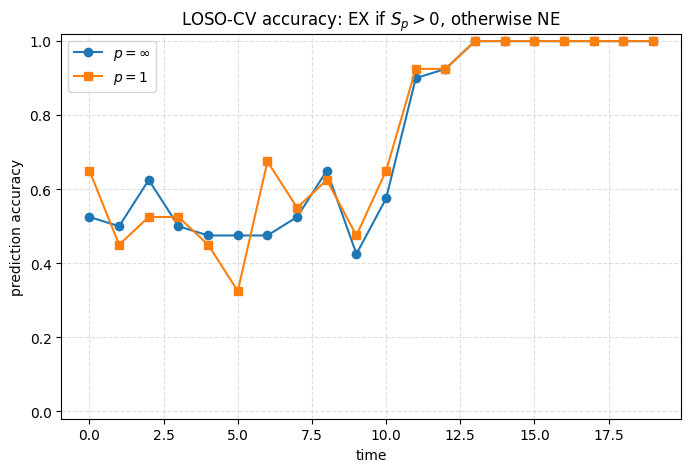

,time_idx,accuracy_Linf,accuracy_L1
0,0,0.525,0.650
1,1,0.500,0.450
2,2,0.625,0.525
3,3,0.500,0.525
4,4,0.475,0.450
5,5,0.475,0.325
6,6,0.475,0.675
7,7,0.525,0.550
8,8,0.650,0.625
9,9,0.425,0.475


In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    loso_time_values,
    accuracy_inf,
    "o-",
    label=r"$p=\infty$",
)
ax.plot(
    loso_time_values,
    accuracy_one,
    "s-",
    label=r"$p=1$",
)

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("time")
ax.set_ylabel("prediction accuracy")
ax.set_title(
    r"LOSO-CV accuracy: EX if $S_p>0$, otherwise NE"
)
ax.grid(ls="--", alpha=0.4)
ax.legend()
plt.show()

accuracy_table

## Fig. 1d-like learned-output summary

This cell produces the compact output used conceptually on the right side of
Fig. 1d: **(1)** one learned minimum perturbation cost field $C_{p,A}$,
**(2)** the learned outcome commitment score
$S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$, and **(3)** LOSO prediction
accuracy as predictive skill.

Set `FIG1D_PATH_COST` to `"max"` ($p=\infty$) or `"sum"` ($p=1$), and set
`FIG1D_COST_TARGET` to `"EX"` or `"NE"`.

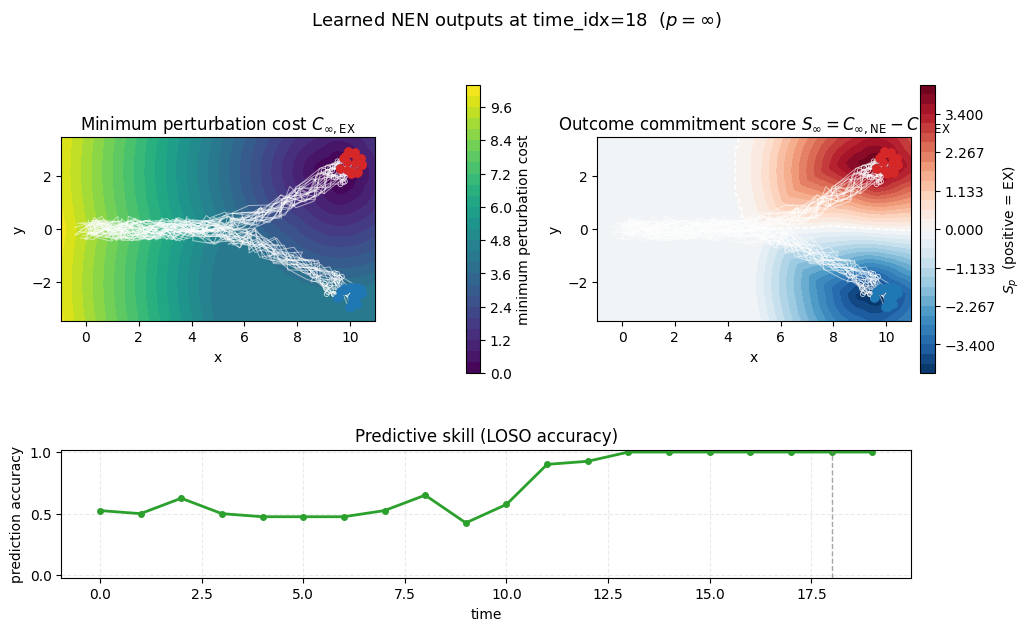

In [27]:
# ----------------------------------------------------------
# Fig. 1d-like compact summary of the learned NEN outputs.
# ----------------------------------------------------------
FIG1D_PATH_COST = "max"      # "max" -> p=infinity, "sum" -> p=1
FIG1D_COST_TARGET = "EX"     # "EX" or "NE"
FIG1D_TIME_IDX = SURFACE_TIME_IDX
SAVE_FIG1D_LIKE = False
FIG1D_OUTPUT_STEM = Path("figures") / "test_simple_Fig1d_like"


def _surface_for_fig1d(path_cost, time_value):
    if path_cost == "max":
        if int(time_value) == int(SURFACE_TIME_IDX):
            return surface_inf, accuracy_inf, r"\infty"
        surface = compute_time_layered_score_surface(
            adata,
            time_value=time_value,
            distance_good_key="eps_distance_sp_good",  # legacy good = EX
            distance_bad_key="eps_distance_sp_bad",    # legacy bad = NE
            path_cost="max",
            score_label=r"$S_\infty=C_{\infty,\mathrm{NE}}-C_{\infty,\mathrm{EX}}$",
        )
        return surface, accuracy_inf, r"\infty"
    if path_cost == "sum":
        if int(time_value) == int(SURFACE_TIME_IDX):
            return surface_one, accuracy_one, "1"
        surface = compute_time_layered_score_surface(
            adata,
            time_value=time_value,
            distance_good_key="eps_sum_distance_sp_good",  # EX
            distance_bad_key="eps_sum_distance_sp_bad",    # NE
            path_cost="sum",
            score_label=r"$S_1=C_{1,\mathrm{NE}}-C_{1,\mathrm{EX}}$",
        )
        return surface, accuracy_one, "1"
    raise ValueError('FIG1D_PATH_COST must be "max" or "sum".')


def _overlay_ensemble(ax, *, time_value):
    seq_values = adata.obs["seq_id"].to_numpy(dtype=int)
    time_values = adata.obs["time_idx"].to_numpy(dtype=int)
    X = np.asarray(adata.X, dtype=float)

    # Whole ensemble trajectories: thin white curves over the learned fields.
    for sid in np.unique(seq_values):
        idx = np.flatnonzero(seq_values == sid)
        idx = idx[np.argsort(time_values[idx])]
        ax.plot(X[idx, 0], X[idx, 1], color="white", lw=0.7, alpha=0.55, zorder=3)

    # States used for same-time entry at the selected forecast time.
    current = np.flatnonzero(time_values == int(time_value))
    ax.scatter(
        X[current, 0], X[current, 1],
        s=13, facecolors="none", edgecolors="white", linewidths=0.55,
        alpha=0.85, zorder=4,
    )

    # Terminal outcomes: upper branch = EX, lower branch = NE.
    terminal_ex = np.flatnonzero(adata.obs["outcome"].to_numpy() == "EX")
    terminal_ne = np.flatnonzero(adata.obs["outcome"].to_numpy() == "NE")
    ax.scatter(X[terminal_ex, 0], X[terminal_ex, 1], s=28, color="tab:red", zorder=5)
    ax.scatter(X[terminal_ne, 0], X[terminal_ne, 1], s=28, color="tab:blue", zorder=5)

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")


surface_fig1d, accuracy_fig1d, p_tex = _surface_for_fig1d(
    FIG1D_PATH_COST,
    FIG1D_TIME_IDX,
)

if FIG1D_COST_TARGET == "EX":
    cost_field = surface_fig1d["cost_EX"]
    cost_title = rf"Minimum perturbation cost $C_{{{p_tex},\mathrm{{EX}}}}$"
elif FIG1D_COST_TARGET == "NE":
    cost_field = surface_fig1d["cost_NE"]
    cost_title = rf"Minimum perturbation cost $C_{{{p_tex},\mathrm{{NE}}}}$"
else:
    raise ValueError('FIG1D_COST_TARGET must be "EX" or "NE".')

score_field = surface_fig1d["score"]  # exactly C_NE - C_EX
finite_score = score_field[np.isfinite(score_field)]
vabs = np.max(np.abs(finite_score)) if finite_score.size else 1.0
if vabs == 0.0:
    vabs = 1.0

fig = plt.figure(figsize=(10.2, 6.2), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[4.0, 1.35])
ax_cost = fig.add_subplot(gs[0, 0])
ax_score = fig.add_subplot(gs[0, 1])
ax_acc = fig.add_subplot(gs[1, :])

# 1) Minimum perturbation cost field C_{p,A}
cost_im = ax_cost.contourf(
    surface_fig1d["X"], surface_fig1d["Y"], cost_field,
    levels=30, cmap="viridis",
)
_overlay_ensemble(ax_cost, time_value=FIG1D_TIME_IDX)
ax_cost.set_title(cost_title)
cbar_cost = fig.colorbar(cost_im, ax=ax_cost, fraction=0.046, pad=0.03)
cbar_cost.set_label(r"minimum perturbation cost")

# 2) Outcome commitment score S_p = C_NE - C_EX
score_im = ax_score.contourf(
    surface_fig1d["X"], surface_fig1d["Y"], score_field,
    levels=np.linspace(-vabs, vabs, 31), cmap="RdBu_r",
    vmin=-vabs, vmax=vabs,
)
ax_score.contour(
    surface_fig1d["X"], surface_fig1d["Y"], score_field,
    levels=[0.0], colors="white", linewidths=1.1, linestyles="--",
)
_overlay_ensemble(ax_score, time_value=FIG1D_TIME_IDX)
ax_score.set_title(
    rf"Outcome commitment score $S_{{{p_tex}}}=C_{{{p_tex},\mathrm{{NE}}}}-C_{{{p_tex},\mathrm{{EX}}}}$"
)
cbar_score = fig.colorbar(score_im, ax=ax_score, fraction=0.046, pad=0.03)
cbar_score.set_label(r"$S_p$  (positive = EX)")

# 3) Strict leave-one-sequence-out predictive skill
ax_acc.plot(loso_time_values, accuracy_fig1d, "o-", color="tab:green", lw=2.0, ms=4)
ax_acc.axvline(FIG1D_TIME_IDX, color="0.5", ls="--", lw=1.0, alpha=0.7)
ax_acc.set_ylim(-0.02, 1.02)
ax_acc.set_xlabel("time")
ax_acc.set_ylabel("prediction accuracy")
ax_acc.set_title("Predictive skill (LOSO accuracy)")
ax_acc.grid(ls="--", alpha=0.25)

fig.suptitle(
    rf"Learned NEN outputs at time_idx={FIG1D_TIME_IDX}  ($p={p_tex}$)",
    fontsize=13,
)

if SAVE_FIG1D_LIKE:
    FIG1D_OUTPUT_STEM.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG1D_OUTPUT_STEM.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(FIG1D_OUTPUT_STEM.with_suffix(".svg"), bbox_inches="tight")

plt.show()

### $\varepsilon_G$ and $\varepsilon_B$ for representative held-out trajectories

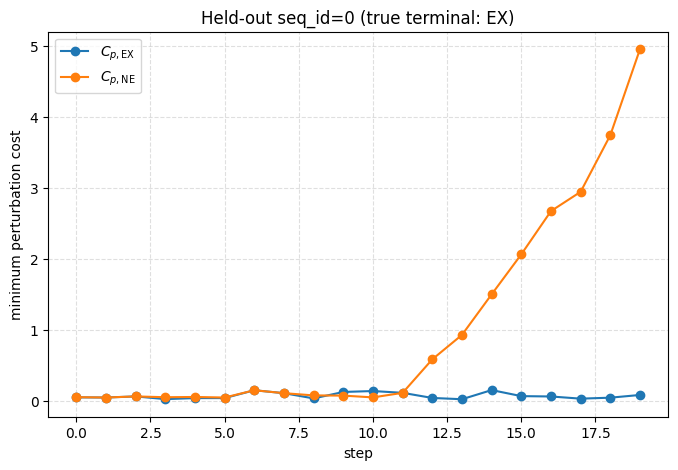

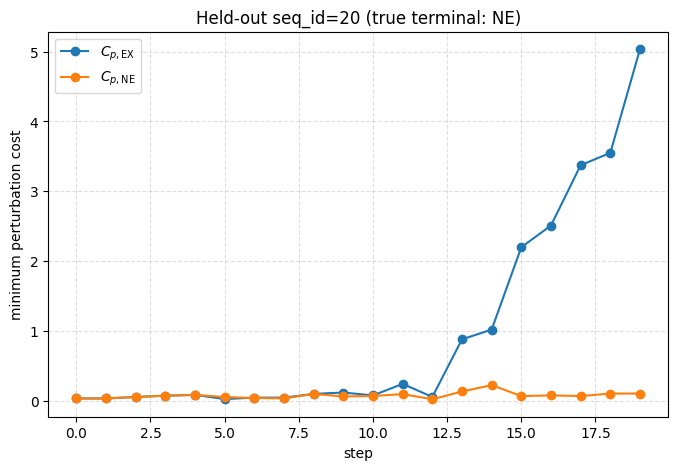

In [28]:
example_ex_seq = terminal_cv.loc[
    terminal_cv["true_outcome"] == "EX", "seq_id"
].iloc[0]
example_ne_seq = terminal_cv.loc[
    terminal_cv["true_outcome"] == "NE", "seq_id"
].iloc[0]

for sid in [example_ex_seq, example_ne_seq]:
    df = cv_eps[cv_eps["seq_id"] == sid].sort_values("step")
    label = df["true_outcome"].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df["step"], df["C_EX"], "o-", label=r"$C_{p,\mathrm{EX}}$")
    ax.plot(df["step"], df["C_NE"], "o-", label=r"$C_{p,\mathrm{NE}}$")
    ax.set_xlabel("step")
    ax.set_ylabel(r"minimum perturbation cost")
    ax.set_title(f"Held-out seq_id={sid} (true terminal: {label})")
    ax.grid(ls="--", alpha=0.4)
    ax.legend()
    plt.show()

### Cross-validated outcome commitment score in state space

We define

$$
\boxed{S_p(x)=C_{p,\mathrm{NE}}(x)-C_{p,\mathrm{EX}}(x)}.
$$

Positive values favor EX and negative values favor NE.

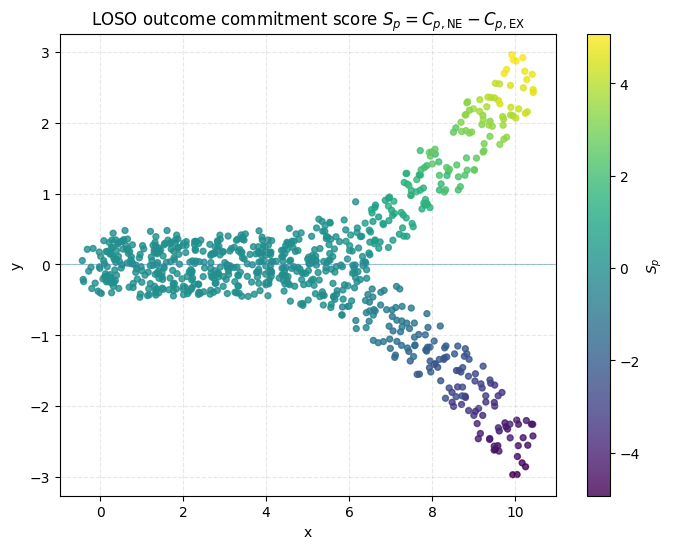

In [29]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    cv_eps["x"],
    cv_eps["y"],
    c=cv_eps["S_p"],
    s=18,
    alpha=0.8,
)
ax.axhline(0.0, lw=0.8, alpha=0.4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(r"LOSO outcome commitment score $S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$")
ax.grid(ls="--", alpha=0.3)
plt.colorbar(sc, ax=ax, label=r"$S_p$")
plt.show()

### Optional: LOSO-CV for $\varepsilon_\Sigma$

Set `RUN_EPS_SUM_CV = True` to repeat LOSO-CV using the time-layered additive ($p=1$) cost.

In [30]:
# p=1 LOSO-CV is already computed above for the S_p heatmap.
# Set this True only if you intentionally want to recompute it.
RUN_EPS_SUM_CV = False

if RUN_EPS_SUM_CV:
    cv_eps_sum = leave_one_sequence_out_cv(
        adata,
        path_cost="sum",
        seq_key="seq_id",
        time_key="time_idx",
        cluster_key="cluster",
        good_cluster_key="good",
        bad_cluster_key="bad",
        cost_matrix_key="cost_matrix",
        verbose=True,
    )

display(cv_eps_sum.head(10))

,path_cost,seq_id,step,time_idx,fraction,global_index,x,y,true_outcome,C_EX,...,correct_outcome,correct_binary,true_label,epsilon_good,epsilon_bad,margin_good,prediction,correct,entry_good_global_index,entry_bad_global_index
0,sum,0,0,0,0.000000,0,0.392749,0.070632,EX,0.045768,...,True,True,good,0.045768,0.058145,0.012377,good,True,160,560
1,sum,0,1,1,0.052632,1,0.710780,0.182812,EX,0.043444,...,True,True,good,0.043444,0.055336,0.011892,good,True,101,701
2,sum,0,2,2,0.105263,2,1.004222,-0.088817,EX,0.097723,...,False,False,good,0.097723,0.059007,-0.038716,bad,False,202,782
3,sum,0,3,3,0.157895,3,1.540252,-0.050838,EX,0.021054,...,True,True,good,0.021054,0.068682,0.047629,good,True,263,263
4,sum,0,4,4,0.210526,4,1.767755,-0.296941,EX,0.035485,...,True,True,good,0.035485,0.083873,0.048389,good,True,164,404
5,sum,0,5,5,0.263158,5,2.275895,0.325172,EX,0.035352,...,True,True,good,0.035352,0.043361,0.008009,good,True,385,505
6,sum,0,6,6,0.315789,6,3.547269,0.008826,EX,0.147697,...,False,False,good,0.147697,0.146134,-0.001564,bad,False,66,546
7,sum,0,7,7,0.368421,7,4.108171,-0.017590,EX,0.104761,...,True,True,good,0.104761,0.137553,0.032792,good,True,27,247
8,sum,0,8,8,0.421053,8,4.065269,-0.273527,EX,0.030749,...,True,True,good,0.030749,0.073283,0.042534,good,True,108,588
9,sum,0,9,9,0.473684,9,4.453780,-0.275514,EX,0.121955,...,False,False,good,0.121955,0.070527,-0.051428,bad,False,209,509


## Pointwise outcome probability for an arbitrary state $x$

A single state does not have an ordinary sample accuracy.  Instead, strict LOSO
scores are used to calibrate the outcome commitment score

$$
S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}
$$

to an extreme-outcome probability

$$
q_{p,t}(s)\approx P(\mathrm{EX}\mid S_p=s,t).
$$

Because positive $S_p$ means stronger commitment toward EX, the isotonic
calibration is monotone increasing.  The complementary probability is
$P(\mathrm{NE}\mid t,x)=1-P(\mathrm{EX}\mid t,x)$.

In [31]:
def fit_timewise_isotonic_calibrators(
    cv_frame,
    *,
    score_column="S_p",
    time_column="time_idx",
    label_column="true_outcome",
    extreme_label="EX",
):
    """Fit q_t(s) ~= P(EX | S=s, time=t) from strict OOS/LOSO scores."""
    calibrators = {}
    summary_rows = []

    for time_value, group in cv_frame.groupby(time_column, sort=True):
        scores = group[score_column].to_numpy(dtype=float)
        y_extreme = (
            group[label_column].astype(str).to_numpy() == extreme_label
        ).astype(float)

        finite = np.isfinite(scores)
        scores = scores[finite]
        y_extreme = y_extreme[finite]
        if scores.size < 2:
            raise ValueError(
                f"Not enough finite calibration scores at time={time_value}."
            )

        model = IsotonicRegression(
            y_min=0.0,
            y_max=1.0,
            increasing=True,
            out_of_bounds="clip",
        )
        model.fit(scores, y_extreme)

        calibrators[int(time_value)] = {
            "model": model,
            "score_min": float(np.min(scores)),
            "score_max": float(np.max(scores)),
            "n_samples": int(scores.size),
            "extreme_fraction": float(np.mean(y_extreme)),
        }
        summary_rows.append(
            {
                "time_idx": int(time_value),
                "n_samples": int(scores.size),
                "score_min": float(np.min(scores)),
                "score_max": float(np.max(scores)),
                "extreme_fraction": float(np.mean(y_extreme)),
            }
        )

    return calibrators, pd.DataFrame(summary_rows)


calibrators_inf, calibration_summary_inf = (
    fit_timewise_isotonic_calibrators(cv_eps)
)
calibrators_one, calibration_summary_one = (
    fit_timewise_isotonic_calibrators(cv_eps_sum)
)

print("L-infinity calibration summary")
display(calibration_summary_inf.head())
print("L1 calibration summary")
display(calibration_summary_one.head())


L-infinity calibration summary


,time_idx,n_samples,score_min,score_max,extreme_fraction
0,0,40,-0.021117,0.008492,0.5
1,1,40,-0.012182,0.025267,0.5
2,2,40,-0.022642,0.024994,0.5
3,3,40,-0.034249,0.053302,0.5
4,4,40,-0.027613,0.027613,0.5


L1 calibration summary


,time_idx,n_samples,score_min,score_max,extreme_fraction
0,0,40,-0.056308,0.047690,0.5
1,1,40,-0.055291,0.047629,0.5
2,2,40,-0.061573,0.062261,0.5
3,3,40,-0.065172,0.090138,0.5
4,4,40,-0.072892,0.062261,0.5


### Reusable evaluator: $C_{p,\mathrm{EX}}$, $C_{p,\mathrm{NE}}$, $S_p$, optimal paths, and calibrated outcome probability

In [32]:
def evaluate_query_with_reliability(
    adata_obj,
    x,
    costs,
    *,
    output_key,
    time_value,
    calibrators,
):
    """Evaluate an external x and attach calibrated pointwise reliability."""
    result = minimum_epsilon_and_paths_to_good_bad(
        adata_obj,
        x,
        costs,
        output_key=output_key,
        time_value=time_value,
    )

    score = float(result.epsilon_bad - result.epsilon_good)
    prediction = "EX" if score > 0.0 else "NE"

    time_key = int(time_value)
    if time_key not in calibrators:
        raise KeyError(
            f"No calibration model is available for time={time_value}."
        )
    calibration = calibrators[time_key]
    probability_ex = float(
        calibration["model"].predict([score])[0]
    )
    probability_ne = 1.0 - probability_ex
    reliability = (
        probability_ex
        if prediction == "EX"
        else probability_ne
    )

    score_min = calibration["score_min"]
    score_max = calibration["score_max"]
    within_support = bool(score_min <= score <= score_max)

    return {
        "path_result": result,
        "C_EX": float(result.epsilon_good),
        "C_NE": float(result.epsilon_bad),
        "S": score,
        "prediction": prediction,
        "P_EX": probability_ex,
        "P_NE": probability_ne,
        "reliability": float(reliability),
        "within_calibration_support": within_support,
        "calibration_score_min": score_min,
        "calibration_score_max": score_max,
    }


### Evaluate the same external query $x$

The query now returns $C_{p,\mathrm{EX}}$, $C_{p,\mathrm{NE}}$, $S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$, $P(\mathrm{EX}\mid t,x)$, $P(\mathrm{NE}\mid t,x)$, and the minimum-cost paths.

In [33]:
query_reliability_inf = evaluate_query_with_reliability(
    adata,
    x_query,
    query_costs,
    output_key="eps_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
    calibrators=calibrators_inf,
)
query_reliability_one = evaluate_query_with_reliability(
    adata,
    x_query,
    query_costs,
    output_key="eps_sum_attracting_basin_sp",
    time_value=QUERY_TIME_IDX,
    calibrators=calibrators_one,
)

query_reliability_table = pd.DataFrame(
    [
        {
            "p": "infinity",
            **{
                key: query_reliability_inf[key]
                for key in (
                    "C_EX",
                    "C_NE",
                    "S",
                    "prediction",
                    "P_EX",
                    "P_NE",
                    "reliability",
                    "within_calibration_support",
                    "calibration_score_min",
                    "calibration_score_max",
                )
            },
        },
        {
            "p": "1",
            **{
                key: query_reliability_one[key]
                for key in (
                    "C_EX",
                    "C_NE",
                    "S",
                    "prediction",
                    "P_EX",
                    "P_NE",
                    "reliability",
                    "within_calibration_support",
                    "calibration_score_min",
                    "calibration_score_max",
                )
            },
        },
    ]
)

display(query_reliability_table)

for p_name, item in [
    ("L-infinity", query_reliability_inf),
    ("L1", query_reliability_one),
]:
    support_note = (
        "inside"
        if item["within_calibration_support"]
        else "OUTSIDE"
    )
    print(
        f"{p_name}: prediction={item['prediction']}, "
        f"estimated reliability={item['reliability']:.3f}, "
        f"P(EX)={item['P_EX']:.3f}, "
        f"score support={support_note} "
        f"[{item['calibration_score_min']:.3f}, "
        f"{item['calibration_score_max']:.3f}]"
    )


,p,C_EX,C_NE,S,prediction,P_EX,P_NE,reliability,within_calibration_support,calibration_score_min,calibration_score_max
0,infinity,0.089276,0.115482,0.026205,EX,0.719194,0.280806,0.719194,True,-0.050080,0.051303
1,1,0.089276,0.162571,0.073294,EX,1.000000,0.000000,1.000000,False,-0.068732,0.062261


L-infinity: prediction=EX, estimated reliability=0.719, P(EX)=0.719, score support=inside [-0.050, 0.051]
L1: prediction=EX, estimated reliability=1.000, P(EX)=1.000, score support=OUTSIDE [-0.069, 0.062]


### Calibration curves at the query time

Dots are strict LOSO outcomes at the same time layer. The solid curve estimates $P(\mathrm{EX}\mid S_p,t)$, the star is the external query, and $S_p=0$ is the fixed neutral-commitment boundary.

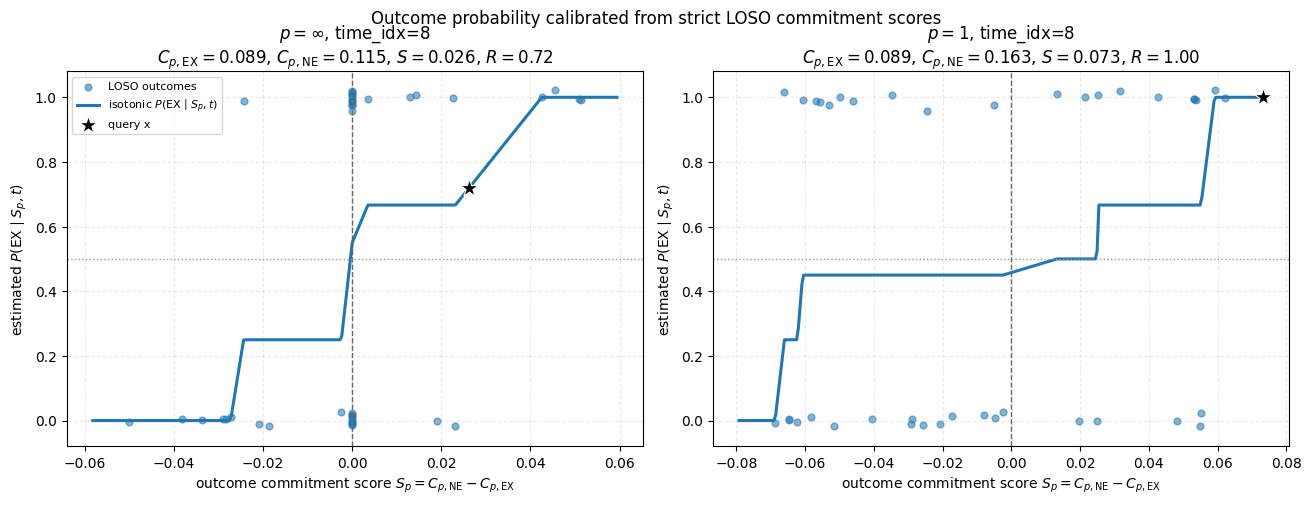

In [34]:
def plot_query_calibration(
    ax,
    *,
    cv_frame,
    calibrators,
    query_info,
    time_value,
    title,
):
    group = cv_frame.loc[
        cv_frame["time_idx"].to_numpy(dtype=int) == int(time_value)
    ].copy()
    scores = group["S_p"].to_numpy(dtype=float)
    y_extreme = (
        group["true_outcome"].astype(str).to_numpy() == "EX"
    ).astype(float)

    calibration = calibrators[int(time_value)]
    s_min = calibration["score_min"]
    s_max = calibration["score_max"]
    if np.isclose(s_min, s_max):
        pad = max(1e-6, 0.1 * max(1.0, abs(s_min)))
        grid = np.linspace(s_min - pad, s_max + pad, 200)
    else:
        pad = 0.08 * (s_max - s_min)
        grid = np.linspace(s_min - pad, s_max + pad, 300)

    p_ex_grid = calibration["model"].predict(grid)

    rng_local = np.random.default_rng(0)
    jitter = rng_local.normal(0.0, 0.018, size=len(y_extreme))
    ax.scatter(
        scores,
        np.clip(y_extreme + jitter, -0.06, 1.06),
        s=24,
        alpha=0.55,
        label="LOSO outcomes",
    )
    ax.plot(
        grid,
        p_ex_grid,
        linewidth=2.2,
        label=r"isotonic $P(\mathrm{EX}\mid S_p,t)$",
    )
    ax.axvline(0.0, color="0.4", ls="--", lw=1.0)
    ax.axhline(0.5, color="0.6", ls=":", lw=1.0)
    ax.scatter(
        [query_info["S"]],
        [query_info["P_EX"]],
        marker="*",
        s=180,
        color="black",
        edgecolor="white",
        linewidth=0.8,
        zorder=10,
        label="query x",
    )

    ax.set_ylim(-0.08, 1.08)
    ax.set_xlabel(r"outcome commitment score $S_p=C_{p,\mathrm{NE}}-C_{p,\mathrm{EX}}$")
    ax.set_ylabel(r"estimated $P(\mathrm{EX}\mid S_p,t)$")
    ax.set_title(
        title
        + "\n"
        + rf"$C_{{p,\mathrm{{EX}}}}={query_info['C_EX']:.3f}$, "
          rf"$C_{{p,\mathrm{{NE}}}}={query_info['C_NE']:.3f}$, "
          rf"$S={query_info['S']:.3f}$, "
          rf"$R={query_info['reliability']:.2f}$"
    )
    ax.grid(ls="--", alpha=0.25)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    constrained_layout=True,
)
plot_query_calibration(
    axes[0],
    cv_frame=cv_eps,
    calibrators=calibrators_inf,
    query_info=query_reliability_inf,
    time_value=QUERY_TIME_IDX,
    title=rf"$p=\infty$, time_idx={QUERY_TIME_IDX}",
)
plot_query_calibration(
    axes[1],
    cv_frame=cv_eps_sum,
    calibrators=calibrators_one,
    query_info=query_reliability_one,
    time_value=QUERY_TIME_IDX,
    title=rf"$p=1$, time_idx={QUERY_TIME_IDX}",
)
axes[0].legend(frameon=True, fontsize=8, loc="best")
fig.suptitle(
    "Outcome probability calibrated from strict LOSO commitment scores",
    y=1.02,
)
plt.show()


### Global accuracy versus pointwise reliability

`accuracy(t)` below is a property of the collection of held-out trajectories,
whereas `reliability(x)` is a property assigned to the single external query
through the calibrated LOSO score distribution.  They should not be called the
same quantity.


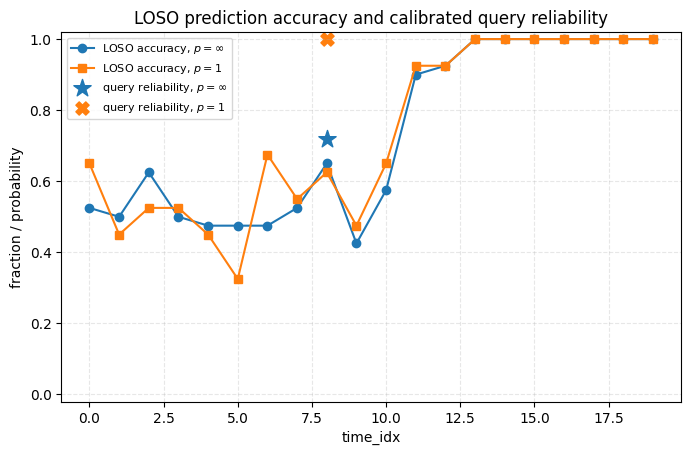

In [35]:
def accuracy_by_time(frame):
    return (
        frame.groupby("time_idx", as_index=False)
        .agg(
            accuracy=("correct_binary", "mean"),
            n=("correct_binary", "size"),
        )
    )

accuracy_inf_time = accuracy_by_time(cv_eps)
accuracy_one_time = accuracy_by_time(cv_eps_sum)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(
    accuracy_inf_time["time_idx"],
    accuracy_inf_time["accuracy"],
    "o-",
    label=r"LOSO accuracy, $p=\infty$",
)
ax.plot(
    accuracy_one_time["time_idx"],
    accuracy_one_time["accuracy"],
    "s-",
    label=r"LOSO accuracy, $p=1$",
)

ax.scatter(
    [QUERY_TIME_IDX],
    [query_reliability_inf["reliability"]],
    marker="*",
    s=170,
    label=r"query reliability, $p=\infty$",
)
ax.scatter(
    [QUERY_TIME_IDX],
    [query_reliability_one["reliability"]],
    marker="X",
    s=90,
    label=r"query reliability, $p=1$",
)

ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("time_idx")
ax.set_ylabel("fraction / probability")
ax.set_title(
    "LOSO prediction accuracy and calibrated query reliability"
)
ax.grid(ls="--", alpha=0.3)
ax.legend(frameon=True, fontsize=8)
plt.show()

### Interpretation for control-oriented use

For an arbitrary state $(t,x)$, the notebook now returns complementary
information:

1. **Outcome prediction:** $P(\mathrm{EX}\mid t,x)$ and
   $P(\mathrm{NE}\mid t,x)$, calibrated from strict LOSO commitment scores.
2. **Outcome accessibility:** the minimum perturbation costs
   $C_{p,\mathrm{EX}}(t,x)$ and $C_{p,\mathrm{NE}}(t,x)$.
3. **Planning:** minimum-cost controlled paths that realize those costs under
   the time-layered ensemble model.

The score

$$
S_p(t,x)=C_{p,\mathrm{NE}}(t,x)-C_{p,\mathrm{EX}}(t,x)
$$

links the learned cost fields to prediction: positive values favor EX and
negative values favor NE.  A state may therefore be strongly predicted toward
one outcome while the alternative outcome remains accessible below a specified
perturbation budget.

## Visualization inventory retained

The original visualizations from the uploaded LOSO/accuracy notebook are kept, and the arbitrary-state optimal-path and pointwise-reliability visualizations are added on top of them.
